<a href="https://colab.research.google.com/github/manojnakidadumbe/LogicMojo-AI-ML-April-26-ManojnaMBhat/blob/main/Lead_Score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [179]:
import warnings
warnings.filterwarnings('ignore')

In [180]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [181]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [182]:
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Lead_Score_Assignment/Leads.csv')
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [183]:
df.shape

(9240, 37)

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [185]:
df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [186]:
missing_percent = df.isnull().sum()/len(df) * 100
missing_percent[missing_percent >30]

,0
Tags,36.287879
Lead Quality,51.590909
Asymmetrique Activity Index,45.649351
Asymmetrique Profile Index,45.649351
Asymmetrique Activity Score,45.649351
Asymmetrique Profile Score,45.649351


In [187]:
df['Lead Quality'].value_counts(dropna = False)

,count
Lead Quality,
NaN,4767
Might be,1560
Not Sure,1092
High in Relevance,637
Worst,601
Low in Relevance,583


In [188]:
missing_values = df.isnull().sum() /len(df) * 100
missing_values[missing_values > 30]


,0
Tags,36.287879
Lead Quality,51.590909
Asymmetrique Activity Index,45.649351
Asymmetrique Profile Index,45.649351
Asymmetrique Activity Score,45.649351
Asymmetrique Profile Score,45.649351


In [189]:
df['Tags'].value_counts(dropna = False)

,count
Tags,
NaN,3353
Will revert after reading the email,2072
Ringing,1203
Interested in other courses,513
Already a student,465
Closed by Horizzon,358
switched off,240
Busy,186
Lost to EINS,175


In [190]:
df[['Asymmetrique Activity Index',
    'Asymmetrique Profile Index',
    'Asymmetrique Activity Score',
    'Asymmetrique Profile Score']].head(10)

,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score
0,02.Medium,02.Medium,15.0,15.0
1,02.Medium,02.Medium,15.0,15.0
2,02.Medium,01.High,14.0,20.0
3,02.Medium,01.High,13.0,17.0
4,02.Medium,01.High,15.0,18.0
5,01.High,02.Medium,17.0,15.0
6,02.Medium,01.High,14.0,20.0
7,02.Medium,02.Medium,15.0,15.0
8,02.Medium,02.Medium,14.0,14.0
9,02.Medium,02.Medium,13.0,16.0


In [191]:
select_percent = (df == 'Select').mean() * 100
select_percent[select_percent > 0]

,0
Specialization,21.017316
How did you hear about X Education,54.577922
Lead Profile,44.870130
City,24.339827


In [192]:
df['Specialization'].value_counts(dropna = False)


,count
Specialization,
Select,1942
NaN,1438
Finance Management,976
Human Resource Management,848
Marketing Management,838
Operations Management,503
Business Administration,403
IT Projects Management,366
Supply Chain Management,349


In [193]:
df.nunique()

,0
Prospect ID,9240
Lead Number,9240
Lead Origin,5
Lead Source,21
Do Not Email,2
Do Not Call,2
Converted,2
TotalVisits,41
Total Time Spent on Website,1731
Page Views Per Visit,114


In [194]:
for col in df.columns:
    if df[col].nunique() <= 2:
        print("\n", col)
        print(df[col].value_counts(dropna=False))


 Do Not Email
Do Not Email
No     8506
Yes     734
Name: count, dtype: int64

 Do Not Call
Do Not Call
No     9238
Yes       2
Name: count, dtype: int64

 Converted
Converted
0    5679
1    3561
Name: count, dtype: int64

 Search
Search
No     9226
Yes      14
Name: count, dtype: int64

 Magazine
Magazine
No    9240
Name: count, dtype: int64

 Newspaper Article
Newspaper Article
No     9238
Yes       2
Name: count, dtype: int64

 X Education Forums
X Education Forums
No     9239
Yes       1
Name: count, dtype: int64

 Newspaper
Newspaper
No     9239
Yes       1
Name: count, dtype: int64

 Digital Advertisement
Digital Advertisement
No     9236
Yes       4
Name: count, dtype: int64

 Through Recommendations
Through Recommendations
No     9233
Yes       7
Name: count, dtype: int64

 Receive More Updates About Our Courses
Receive More Updates About Our Courses
No    9240
Name: count, dtype: int64

 Update me on Supply Chain Content
Update me on Supply Chain Content
No    9240
Name: count

In [195]:
df[['TotalVisits',
    'Total Time Spent on Website',
    'Page Views Per Visit',
    'Asymmetrique Activity Score',
    'Asymmetrique Profile Score']].describe()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,3.445238,487.698268,2.362820,14.306252,16.344883
std,4.854853,548.021466,2.161418,1.386694,1.811395
min,0.000000,0.000000,0.000000,7.000000,11.000000
25%,1.000000,12.000000,1.000000,14.000000,15.000000
50%,3.000000,248.000000,2.000000,14.000000,16.000000
75%,5.000000,936.000000,3.000000,15.000000,18.000000
max,251.000000,2272.000000,55.000000,18.000000,20.000000


array([[<Axes: title={'center': 'TotalVisits'}>,
        <Axes: title={'center': 'Total Time Spent on Website'}>],
       [<Axes: title={'center': 'Page Views Per Visit'}>,
        <Axes: title={'center': 'Asymmetrique Activity Score'}>],
       [<Axes: title={'center': 'Asymmetrique Profile Score'}>, <Axes: >]],
      dtype=object)

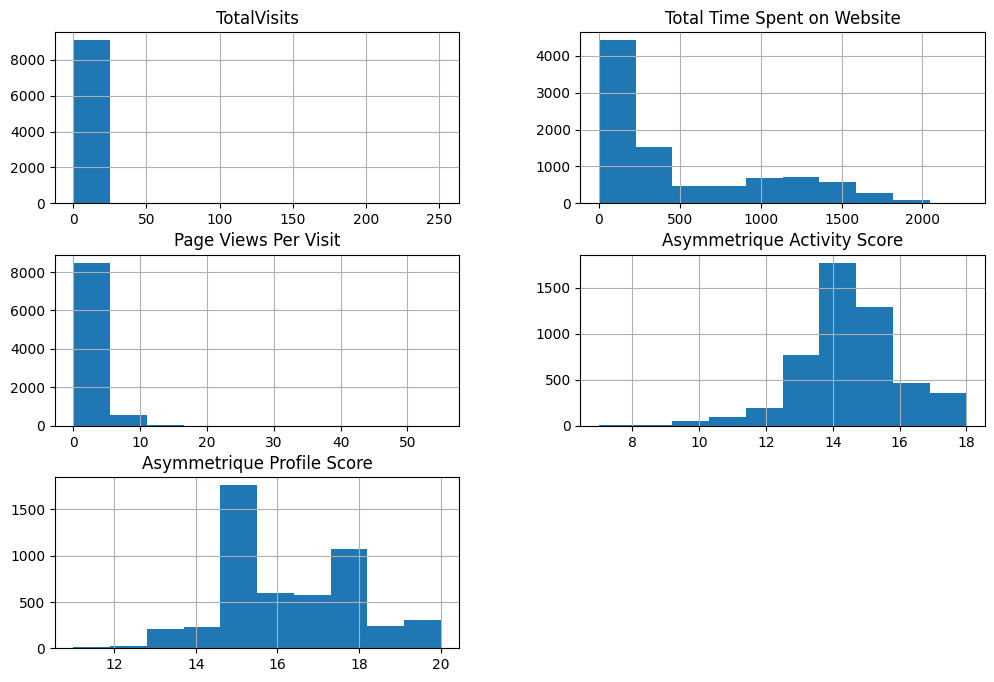

In [196]:
df[['TotalVisits',
    'Total Time Spent on Website',
    'Page Views Per Visit',
    'Asymmetrique Activity Score',
    'Asymmetrique Profile Score']].hist(figsize=(12, 8))

In [197]:
drop_cols = [
    'Lead Quality',
    'Asymmetrique Activity Index',
    'Asymmetrique Profile Index',
    'Asymmetrique Activity Score',
    'Asymmetrique Profile Score',
    'Specialization',
    'How did you hear about X Education',
    'Lead Profile',
    'City',
    'Magazine',
    'Receive More Updates About Our Courses',
    'Update me on Supply Chain Content',
    'Get updates on DM Content',
    'I agree to pay the amount through cheque'
]

df = df.drop(columns=drop_cols)

In [198]:
df.columns


Index(['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source',
       'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits',
       'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity',
       'Country', 'What is your current occupation',
       'What matters most to you in choosing a course', 'Search',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations', 'Tags',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

In [199]:
df.isnull().sum().sort_values(ascending=False)

,0
Tags,3353
What matters most to you in choosing a course,2709
What is your current occupation,2690
Country,2461
Page Views Per Visit,137
TotalVisits,137
Last Activity,103
Lead Source,36
Do Not Call,0
Converted,0


In [200]:
df['Tags'] = df['Tags'].fillna('Not Specified')

In [201]:
df['What is your current occupation'] = \
    df['What is your current occupation'].fillna('Not Specified')

In [202]:
df['Country'] = df['Country'].fillna('Not Specified')

In [203]:
df['TotalVisits'] = df['TotalVisits'].fillna(df['TotalVisits'].median())

df['Page Views Per Visit'] = \
    df['Page Views Per Visit'].fillna(df['Page Views Per Visit'].median())

In [204]:
df['Last Activity'] = df['Last Activity'].fillna('Not Specified')

In [205]:
df['Lead Source'] = df['Lead Source'].fillna('Not Specified')

In [206]:
df.isnull().sum().sort_values(ascending=False)

,0
What matters most to you in choosing a course,2709
Lead Number,0
Prospect ID,0
Lead Source,0
Do Not Email,0
Do Not Call,0
Lead Origin,0
Converted,0
TotalVisits,0
Page Views Per Visit,0


In [207]:
cat_cols = df.select_dtypes(include='object').columns

cat_cols

Index(['Prospect ID', 'Lead Origin', 'Lead Source', 'Do Not Email',
       'Do Not Call', 'Last Activity', 'Country',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Search',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations', 'Tags',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

In [208]:
for col in cat_cols:
    print("\n", "="*40, col)
    print(df[col].value_counts())


 ======================================== Prospect ID
Prospect ID
571b5c8e-a5b2-4d57-8574-f2ffb06fdeff    1
7927b2df-8bba-4d29-b9a2-b6e0beafe620    1
2a272436-5132-4136-86fa-dcc88c88f482    1
8cc8c611-a219-4f35-ad23-fdfd2656bd8a    1
0cc2df48-7cf4-4e39-9de9-19797f9b38cc    1
                                       ..
8bf76a52-2478-476b-8618-1688e07874ad    1
9bc8ce93-6144-49e0-9f9d-080fc980f83c    1
2a369e35-ca95-4ca9-9e4f-9d27175aa320    1
af465dfc-7204-4130-9e05-33231863c4b5    1
cfa0128c-a0da-4656-9d47-0aa4e67bf690    1
Name: count, Length: 9240, dtype: int64

 ======================================== Lead Origin
Lead Origin
Landing Page Submission    4886
API                        3580
Lead Add Form               718
Lead Import                  55
Quick Add Form                1
Name: count, dtype: int64

 ======================================== Lead Source
Lead Source
Google               2868
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Referen

In [209]:
df_cat = ['Lead Origin',
          'Lead Source',
          'Do Not Email',
          'Do Not Call',
          'Last Activity',
          'Country',
          'What is your current occupation',
          'Search',
          'Newspaper Article',
          'X Education Forums',
          'Newspaper',
          'Digital Advertisement',
          'Through Recommendations',
          'A free copy of Mastering The Interview',
          'Last Notable Activity'
         ]

In [210]:
l = df.nunique()
z = l[l.values <= 2]
binary_var = list(z.index)
binary_var

['Do Not Email',
 'Do Not Call',
 'Converted',
 'Search',
 'Newspaper Article',
 'X Education Forums',
 'Newspaper',
 'Digital Advertisement',
 'Through Recommendations',
 'A free copy of Mastering The Interview']

In [211]:
l = df[df_cat].nunique()
z = l[l.values > 2]
non_binary_var = list(z.index)
non_binary_var

['Lead Origin',
 'Lead Source',
 'Last Activity',
 'Country',
 'What is your current occupation',
 'Last Notable Activity']

In [212]:
Conversion_rate = (sum(df['Converted'])/len(df['Converted'].index))*100
Conversion_rate

38.53896103896104

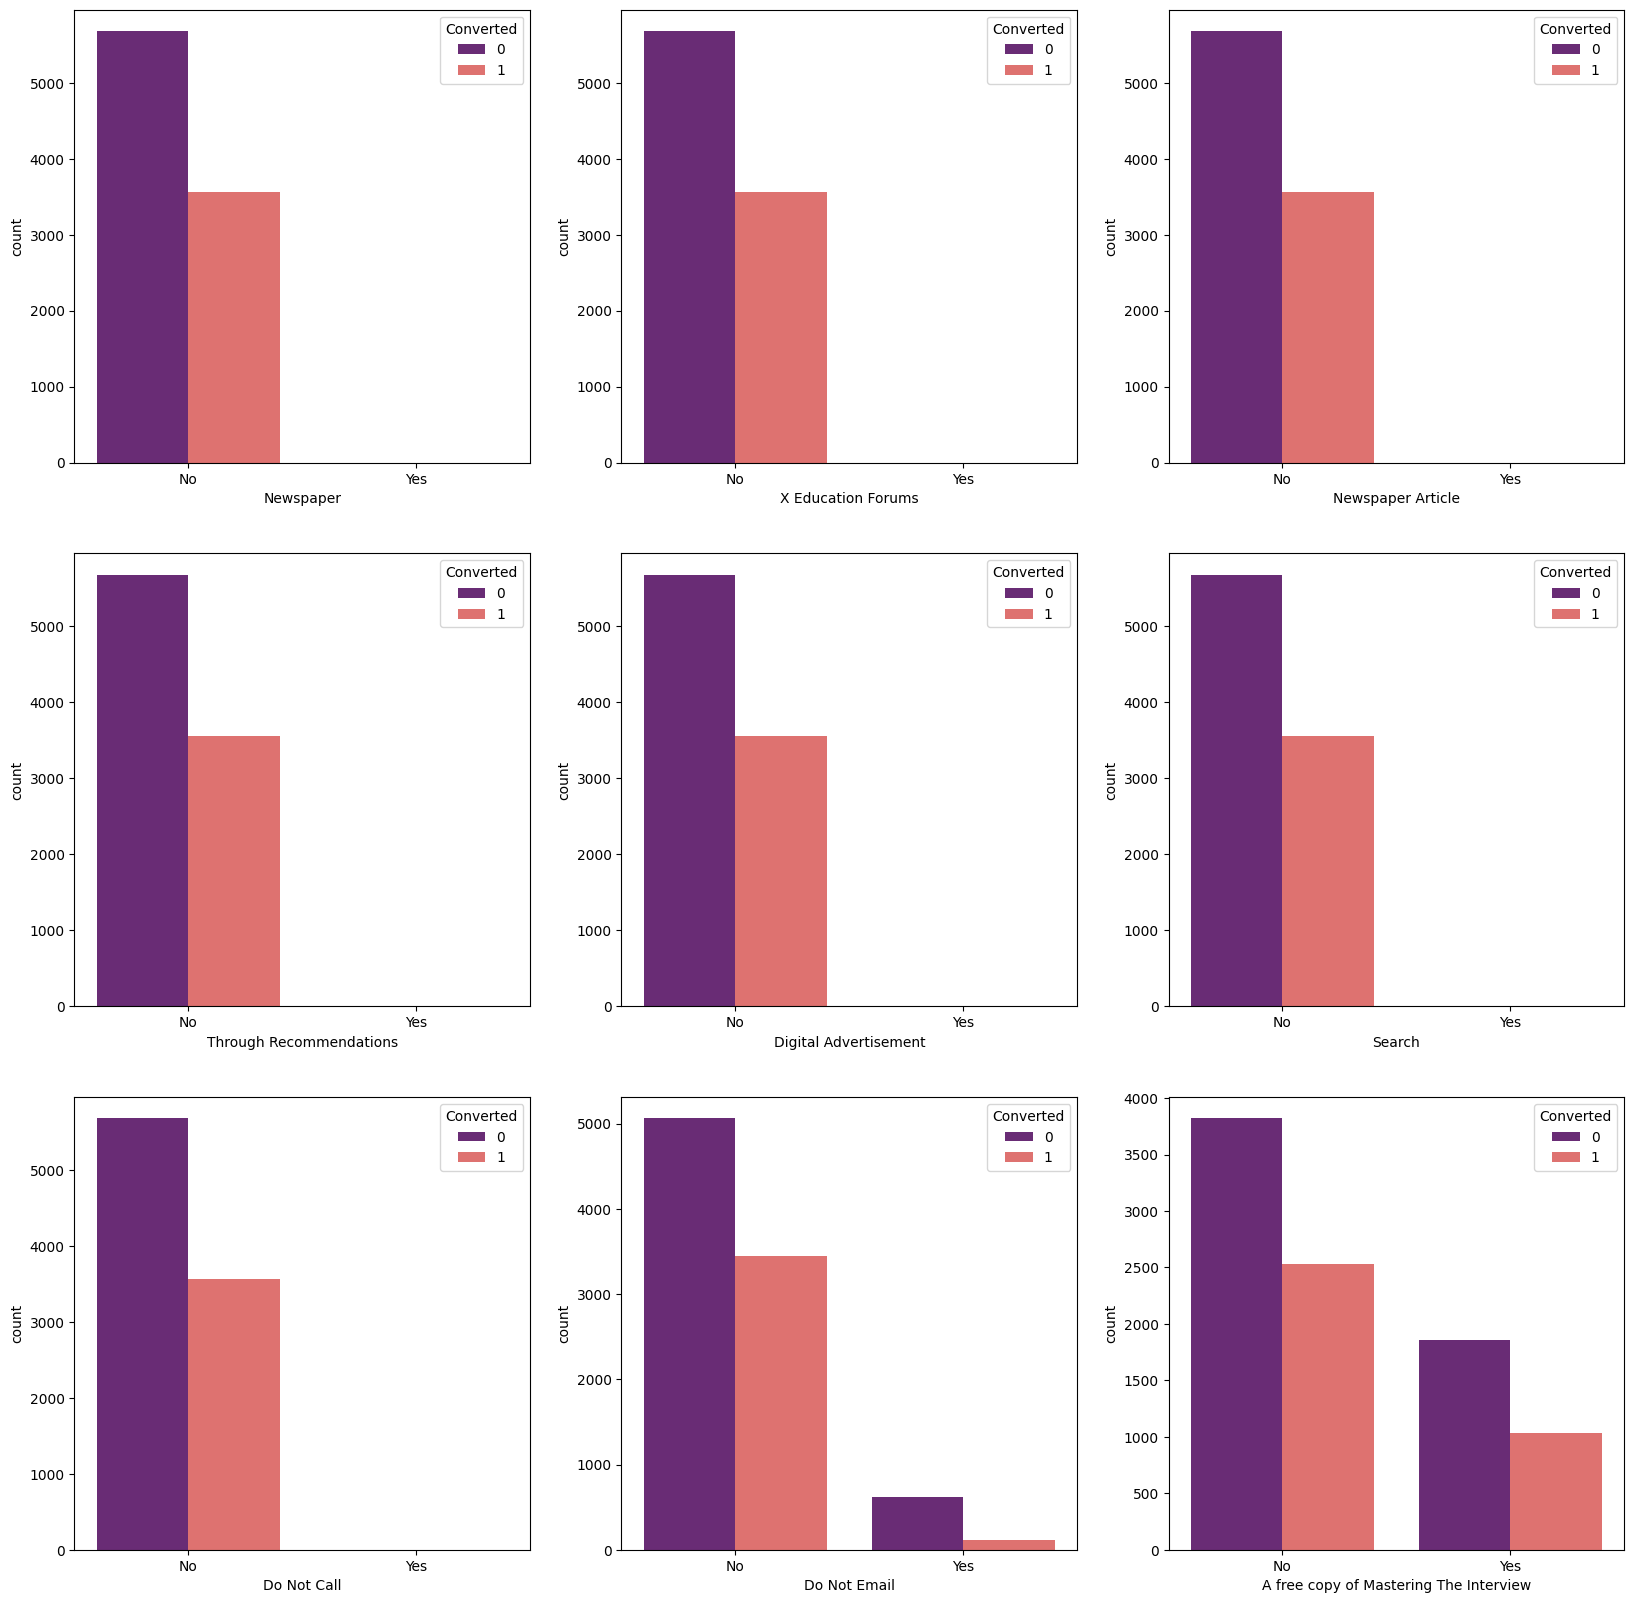

In [213]:
#Analysing Categorical variables

plt.figure(figsize=(20,20))
plt.subplot(331)
sns.countplot(data = df, x=  'Newspaper', order=df['Newspaper'].value_counts().index,hue = df['Converted'],palette='magma')

plt.subplot(332)
sns.countplot(data = df, x= 'X Education Forums', order=df['X Education Forums'].value_counts().index,hue = df['Converted'],palette='magma')

plt.subplot(333)
sns.countplot(data = df, x=  'Newspaper Article', order=df['Newspaper Article'].value_counts().index,hue = df['Converted'],palette='magma')

plt.subplot(334)
sns.countplot(data = df, x=  'Through Recommendations', order=df['Through Recommendations'].value_counts().index,hue = df['Converted'],palette='magma')

plt.subplot(335)
sns.countplot(data = df, x=  'Digital Advertisement' , order=df[ 'Digital Advertisement' ].value_counts().index,hue = df['Converted'],palette='magma')

plt.subplot(336)
sns.countplot(data = df, x= 'Search', order=df['Search'].value_counts().index,hue = df['Converted'],palette='magma')

plt.subplot(337)
sns.countplot(data = df, x=  'Do Not Call', order=df['Do Not Call'].value_counts().index,hue = df['Converted'],palette='magma')

plt.subplot(338)
sns.countplot(data = df, x=  'Do Not Email', order=df['Do Not Email'].value_counts().index,hue = df['Converted'],palette='magma')

plt.subplot(339)
sns.countplot(data = df, x=  'A free copy of Mastering The Interview', order=df['A free copy of Mastering The Interview'].value_counts().index,hue = df['Converted'],palette='magma')


plt.show()

In [214]:
df=df.drop(["Newspaper","X Education Forums","Newspaper Article",
                          "Through Recommendations","Digital Advertisement",
                          "Search","Do Not Call"],axis=1)

In [215]:
df_cat = ['Lead Origin',
          'Lead Source',
          'Do Not Email',
          'Last Activity',
          'Country',
          'What is your current occupation',
          'A free copy of Mastering The Interview',
          'Last Notable Activity'
         ]

In [216]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,What is your current occupation,What matters most to you in choosing a course,Tags,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,0,0.0,0,0.0,Page Visited on Website,Not Specified,Unemployed,Better Career Prospects,Interested in other courses,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,0,5.0,674,2.5,Email Opened,India,Unemployed,Better Career Prospects,Ringing,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,1,2.0,1532,2.0,Email Opened,India,Student,Better Career Prospects,Will revert after reading the email,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,0,1.0,305,1.0,Unreachable,India,Unemployed,Better Career Prospects,Ringing,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,1,2.0,1428,1.0,Converted to Lead,India,Unemployed,Better Career Prospects,Will revert after reading the email,No,Modified


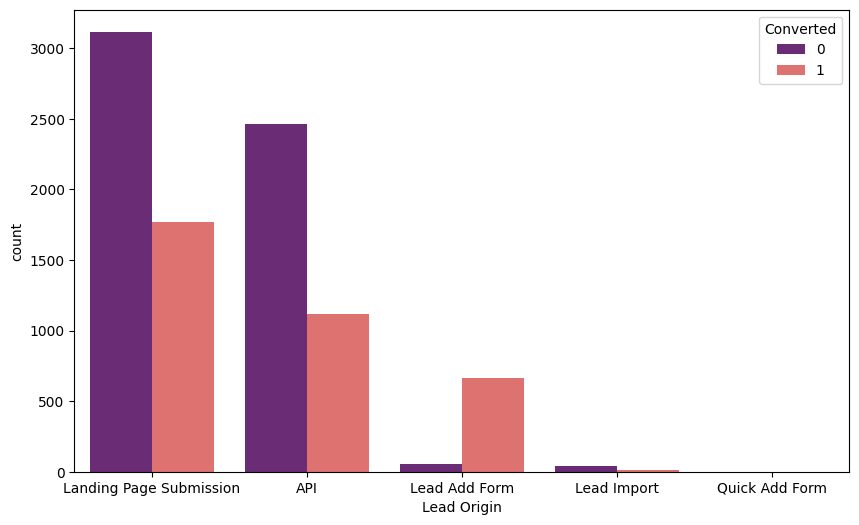

In [217]:
# plotting Lead Origin count plot
plt.figure(figsize = (10,6))
sns.countplot(data = df, x= 'Lead Origin', order=df['Lead Origin'].value_counts().index,hue = df['Converted'],palette='magma')
plt.show()

<Axes: xlabel='Lead Source', ylabel='count'>

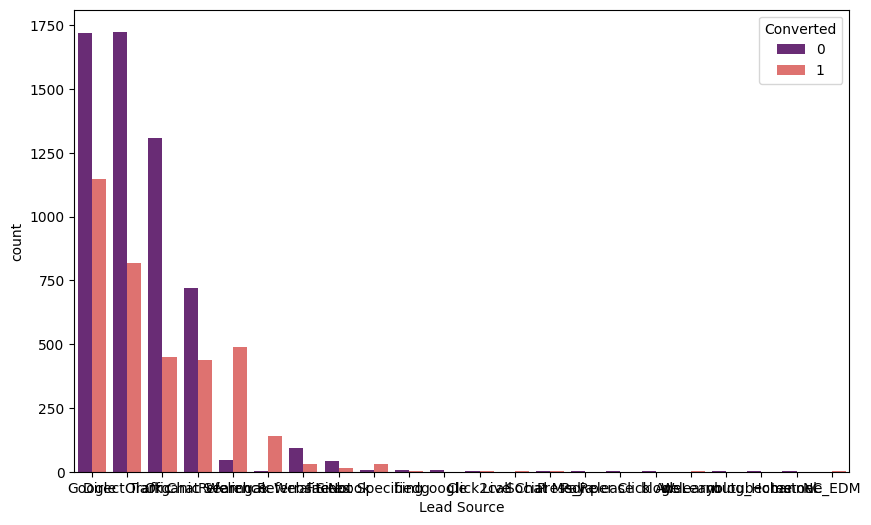

In [218]:
#Plotting Lead source count plot
plt.figure(figsize = (10,6))

sns.countplot(data = df, x=  'Lead Source', order=df['Lead Source'].value_counts().index,hue = df['Converted'],palette='magma')


<Axes: xlabel='Last Activity', ylabel='count'>

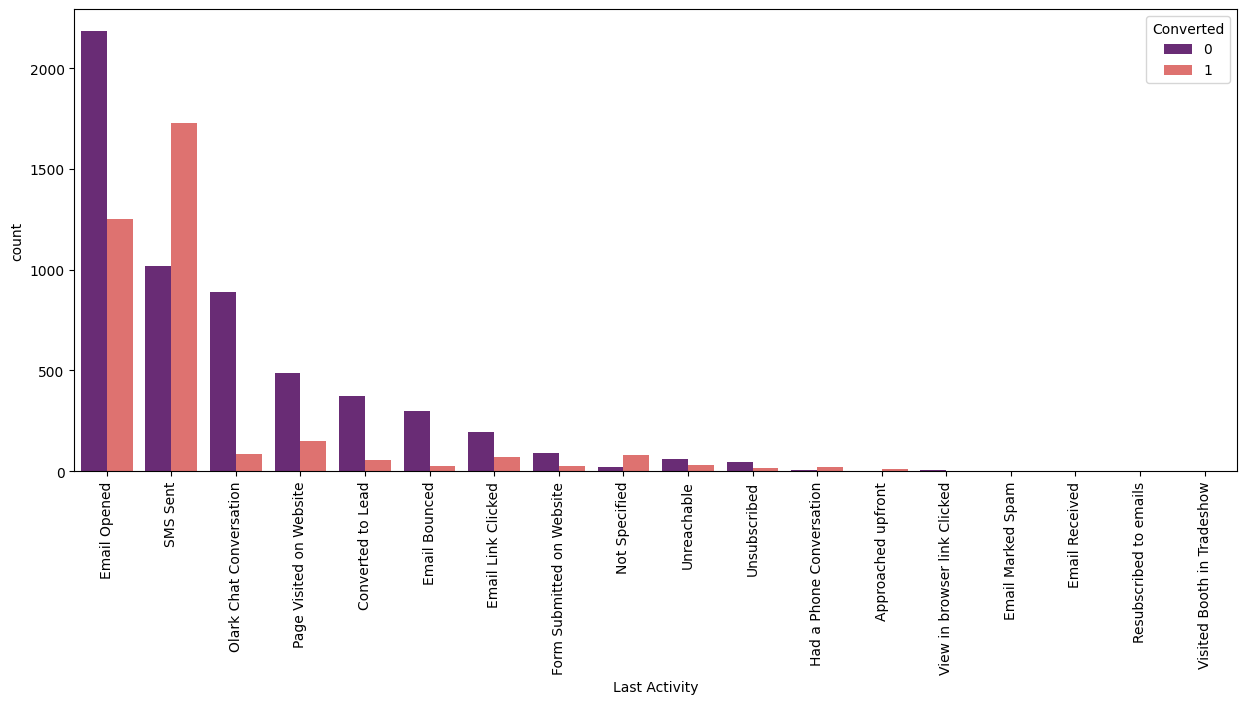

In [219]:
#Plotting Last Activity with counts
plt.figure(figsize = (15,6))
plt.xticks(rotation=90)
sns.countplot(data = df, x=  'Last Activity', order=df['Last Activity'].value_counts().index,hue = df['Converted'],palette='magma')


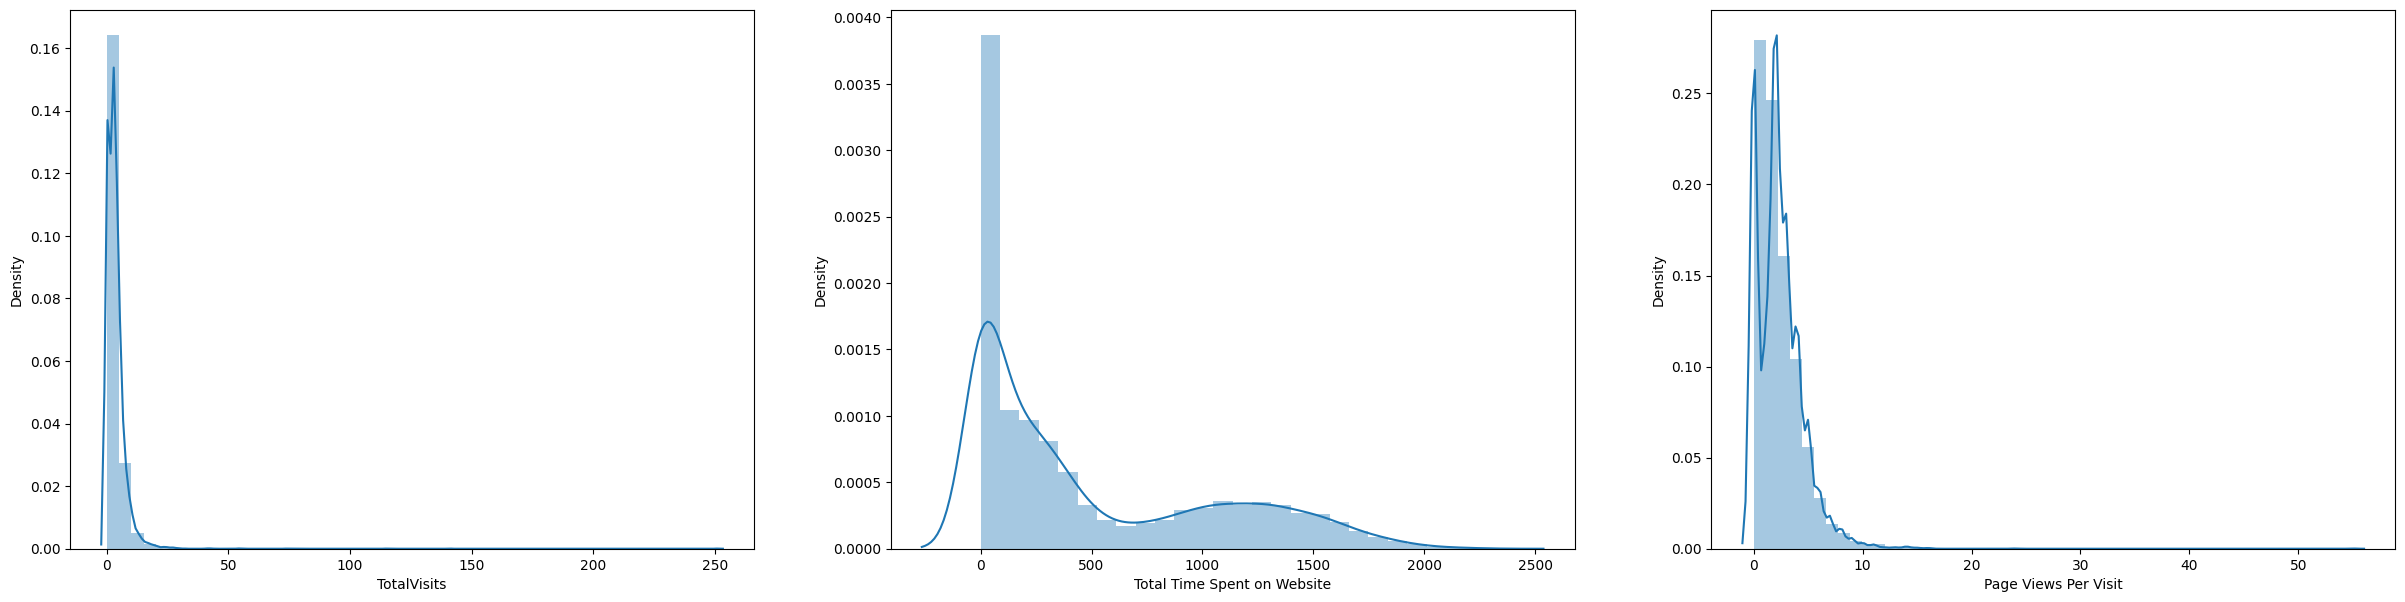

In [220]:
# Getting Genral Idea About Numeric Variables

plt.figure(figsize =(30,7))
plt.subplot(1,3,1)
sns.distplot(df['TotalVisits'])


plt.subplot(1,3,2)
sns.distplot(df['Total Time Spent on Website'])


plt.subplot(1,3,3)
sns.distplot(df['Page Views Per Visit'])
plt.show()

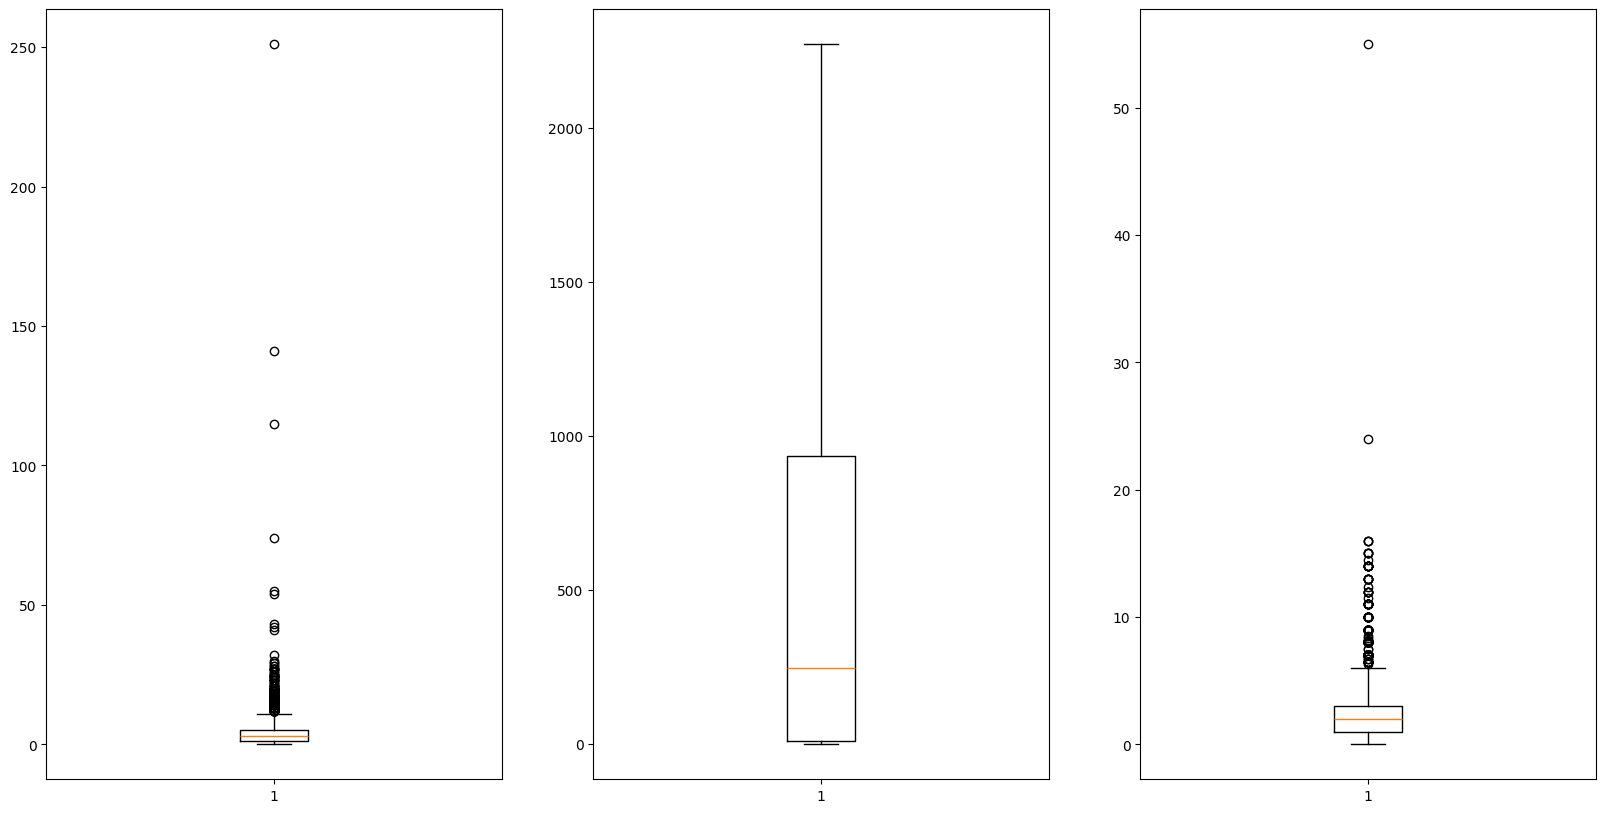

In [221]:
#Checking for outliers

plt.figure(figsize = (20,10))
plt.subplot(1,3,1)
plt.boxplot(df['TotalVisits'])


plt.subplot(1,3,2)
plt.boxplot(df['Total Time Spent on Website'])


plt.subplot(1,3,3)
plt.boxplot(df['Page Views Per Visit'])
plt.show()

In [222]:
df_num = ['TotalVisits',
          'Total Time Spent on Website',
          'Page Views Per Visit'
          ]

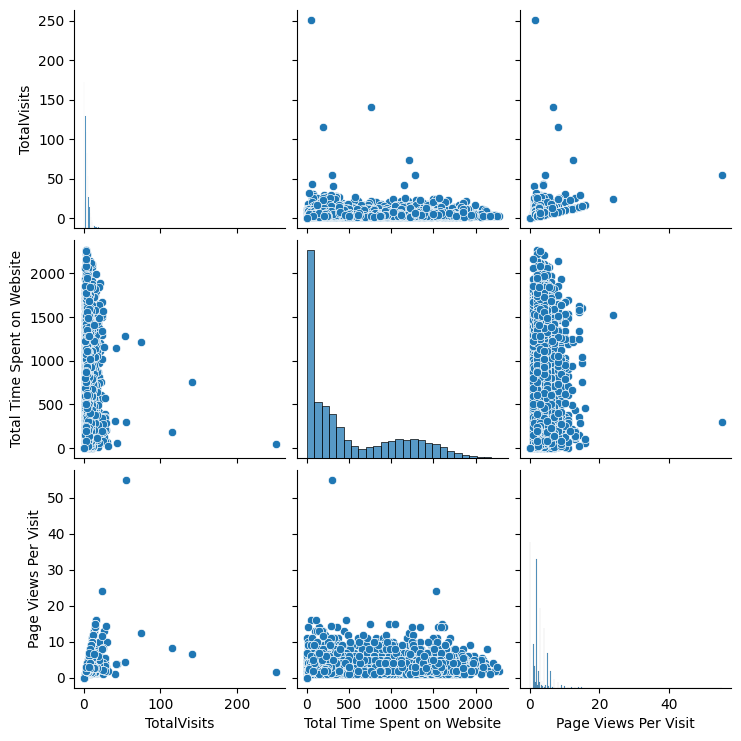

In [223]:
# General trend on collinearity between numical variables

sns.pairplot(df[df_num])

In [224]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,What is your current occupation,What matters most to you in choosing a course,Tags,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,0,0.0,0,0.0,Page Visited on Website,Not Specified,Unemployed,Better Career Prospects,Interested in other courses,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,0,5.0,674,2.5,Email Opened,India,Unemployed,Better Career Prospects,Ringing,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,1,2.0,1532,2.0,Email Opened,India,Student,Better Career Prospects,Will revert after reading the email,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,0,1.0,305,1.0,Unreachable,India,Unemployed,Better Career Prospects,Ringing,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,1,2.0,1428,1.0,Converted to Lead,India,Unemployed,Better Career Prospects,Will revert after reading the email,No,Modified


In [225]:
# List of variables to map

varlist =  ['Do Not Email', 'A free copy of Mastering The Interview']

# Defining the map function
def binary_map(x):
    return x.map({'Yes': 1, "No": 0})

# Applying the function to the housing list
df[varlist] = df[varlist].apply(binary_map)
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,What is your current occupation,What matters most to you in choosing a course,Tags,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,0,0,0.0,0,0.0,Page Visited on Website,Not Specified,Unemployed,Better Career Prospects,Interested in other courses,0,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,0,0,5.0,674,2.5,Email Opened,India,Unemployed,Better Career Prospects,Ringing,0,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,0,1,2.0,1532,2.0,Email Opened,India,Student,Better Career Prospects,Will revert after reading the email,1,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,0,0,1.0,305,1.0,Unreachable,India,Unemployed,Better Career Prospects,Ringing,0,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,0,1,2.0,1428,1.0,Converted to Lead,India,Unemployed,Better Career Prospects,Will revert after reading the email,0,Modified


In [226]:
df_cat = ['Lead Origin',
         'Lead Source',
         'Last Activity',
         'Country',
         'What is your current occupation',
         'Last Notable Activity']

In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 16 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9240 non-null   object 
 4   Do Not Email                                   9240 non-null   int64  
 5   Converted                                      9240 non-null   int64  
 6   TotalVisits                                    9240 non-null   float64
 7   Total Time Spent on Website                    9240 non-null   int64  
 8   Page Views Per Visit                           9240 non-null   float64
 9   Last Activity                                  9240 

In [228]:
df_cat

['Lead Origin',
 'Lead Source',
 'Last Activity',
 'Country',
 'What is your current occupation',
 'Last Notable Activity']

In [229]:
# Categorical columns
df_cat = [
    'Lead Origin',
    'Lead Source',
    'Last Activity',
    'Country',
    'What is your current occupation',
    'Last Notable Activity'
]

# Group rare Lead Source categories
df['Lead Source'] = df['Lead Source'].replace(
    ['Facebook', 'Live Chat', 'NC_EDM', 'Pay per Click Ads',
     'Press_Release', 'Social Media', 'WeLearn', 'bing', 'blog',
     'google', 'testone', 'welearnblog_Home', 'youtubechannel',
     'Not Specified'],
    'Other'
)

# Group rare Country categories
country_counts = df['Country'].value_counts()
df['Country'] = df['Country'].apply(
    lambda x: x if country_counts.get(x, 0) >= 100 else 'Other'
)

# Group small Occupation categories
df['What is your current occupation'] = df[
    'What is your current occupation'
].replace(
    ['Housewife', 'Other'],
    'Other'
)

# Create dummy variables
dummy1 = pd.get_dummies(
    df[df_cat],
    drop_first=True,
    dtype=int
)

# Remove original categorical columns and add dummy columns
df = pd.concat(
    [df.drop(df_cat, axis=1), dummy1],
    axis=1
)

# Check final shape
print(df.shape)

(9240, 61)


In [230]:
print(df.columns.tolist())

['Prospect ID', 'Lead Number', 'Do Not Email', 'Converted', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'What matters most to you in choosing a course', 'Tags', 'A free copy of Mastering The Interview', 'Lead Origin_Landing Page Submission', 'Lead Origin_Lead Add Form', 'Lead Origin_Lead Import', 'Lead Origin_Quick Add Form', 'Lead Source_Direct Traffic', 'Lead Source_Google', 'Lead Source_Olark Chat', 'Lead Source_Organic Search', 'Lead Source_Other', 'Lead Source_Reference', 'Lead Source_Referral Sites', 'Lead Source_Welingak Website', 'Last Activity_Converted to Lead', 'Last Activity_Email Bounced', 'Last Activity_Email Link Clicked', 'Last Activity_Email Marked Spam', 'Last Activity_Email Opened', 'Last Activity_Email Received', 'Last Activity_Form Submitted on Website', 'Last Activity_Had a Phone Conversation', 'Last Activity_Not Specified', 'Last Activity_Olark Chat Conversation', 'Last Activity_Page Visited on Website', 'Last Activity_Resubscribed to em

In [231]:
df.drop('What matters most to you in choosing a course', axis=1, inplace=True)

In [232]:
df.shape

(9240, 60)

In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 60 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Prospect ID                                           9240 non-null   object 
 1   Lead Number                                           9240 non-null   int64  
 2   Do Not Email                                          9240 non-null   int64  
 3   Converted                                             9240 non-null   int64  
 4   TotalVisits                                           9240 non-null   float64
 5   Total Time Spent on Website                           9240 non-null   int64  
 6   Page Views Per Visit                                  9240 non-null   float64
 7   Tags                                                  9240 non-null   object 
 8   A free copy of Mastering The Interview                9240

In [234]:
pd.crosstab(df['Tags'], df['Converted'], normalize='index') * 100

Converted,0,1
Tags,,
Already a student,99.354839,0.645161
Busy,43.548387,56.451613
Closed by Horizzon,0.558659,99.441341
Diploma holder (Not Eligible),98.412698,1.587302
Graduation in progress,93.693694,6.306306
In confusion whether part time or DLP,80.000000,20.000000
Interested in full time MBA,97.435897,2.564103
Interested in Next batch,0.000000,100.000000
Interested in other courses,97.465887,2.534113


In [235]:
df.drop('Tags', axis=1, inplace=True)

In [236]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 59 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Prospect ID                                           9240 non-null   object 
 1   Lead Number                                           9240 non-null   int64  
 2   Do Not Email                                          9240 non-null   int64  
 3   Converted                                             9240 non-null   int64  
 4   TotalVisits                                           9240 non-null   float64
 5   Total Time Spent on Website                           9240 non-null   int64  
 6   Page Views Per Visit                                  9240 non-null   float64
 7   A free copy of Mastering The Interview                9240 non-null   int64  
 8   Lead Origin_Landing Page Submission                   9240

In [237]:
df_num

['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

In [238]:
df_num = df.iloc[:,2:]
df_num.head()

,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Direct Traffic,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Other,Lead Source_Reference,Lead Source_Referral Sites,Lead Source_Welingak Website,Last Activity_Converted to Lead,Last Activity_Email Bounced,Last Activity_Email Link Clicked,Last Activity_Email Marked Spam,Last Activity_Email Opened,Last Activity_Email Received,Last Activity_Form Submitted on Website,Last Activity_Had a Phone Conversation,Last Activity_Not Specified,Last Activity_Olark Chat Conversation,Last Activity_Page Visited on Website,Last Activity_Resubscribed to emails,Last Activity_SMS Sent,Last Activity_Unreachable,Last Activity_Unsubscribed,Last Activity_View in browser link Clicked,Last Activity_Visited Booth in Tradeshow,Country_Not Specified,Country_Other,What is your current occupation_Not Specified,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Email Link Clicked,Last Notable Activity_Email Marked Spam,Last Notable Activity_Email Opened,Last Notable Activity_Email Received,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,0,0,5.0,674,2.5,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,0,1,2.0,1532,2.0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0,0,1.0,305,1.0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,0,1,2.0,1428,1.0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


<Axes: >

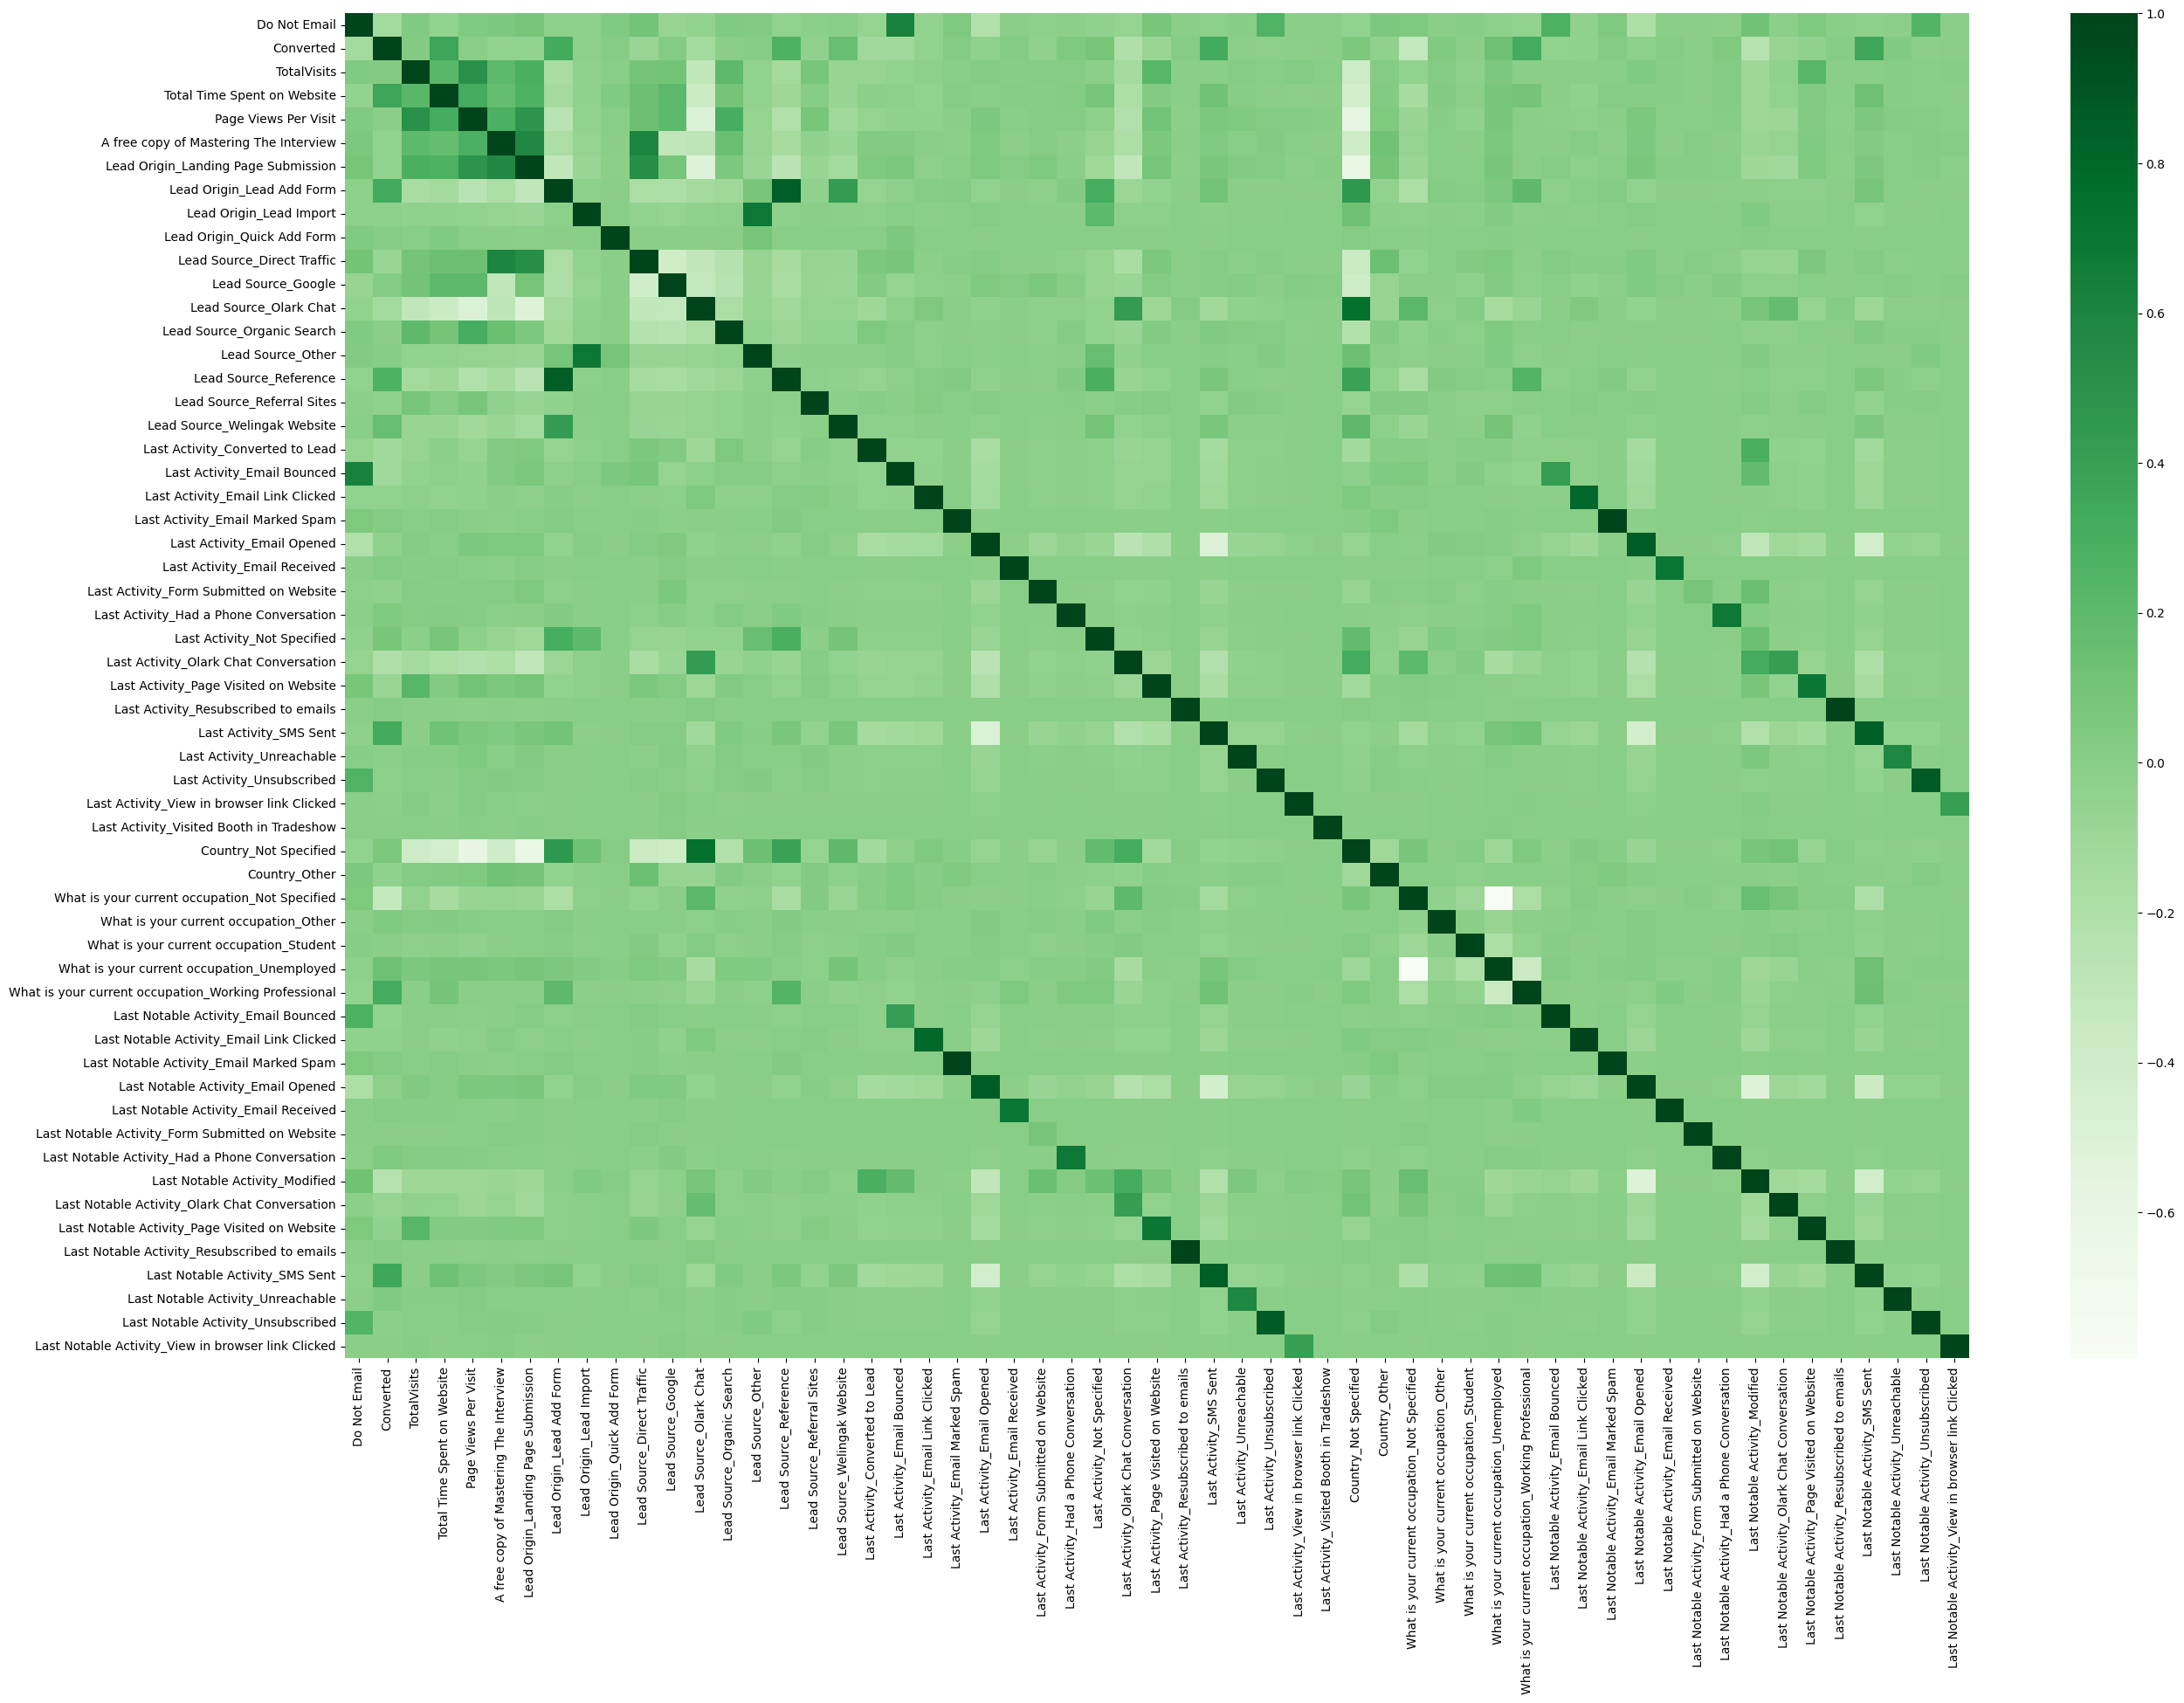

In [239]:
correlation = df_num.corr()
plt.figure(figsize=(30,20))
sns.heatmap(correlation, annot = False, cmap = 'Greens')

In [240]:
correlation

,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Direct Traffic,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Other,Lead Source_Reference,Lead Source_Referral Sites,Lead Source_Welingak Website,Last Activity_Converted to Lead,Last Activity_Email Bounced,Last Activity_Email Link Clicked,Last Activity_Email Marked Spam,Last Activity_Email Opened,Last Activity_Email Received,Last Activity_Form Submitted on Website,Last Activity_Had a Phone Conversation,Last Activity_Not Specified,Last Activity_Olark Chat Conversation,Last Activity_Page Visited on Website,Last Activity_Resubscribed to emails,Last Activity_SMS Sent,Last Activity_Unreachable,Last Activity_Unsubscribed,Last Activity_View in browser link Clicked,Last Activity_Visited Booth in Tradeshow,Country_Not Specified,Country_Other,What is your current occupation_Not Specified,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Email Link Clicked,Last Notable Activity_Email Marked Spam,Last Notable Activity_Email Opened,Last Notable Activity_Email Received,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
Do Not Email,1.000000,-0.135580,0.033640,-0.046374,0.033404,0.055762,0.095304,-0.020983,-0.017529,0.035416,0.109314,-0.071647,-0.051436,0.034295,0.032001,-0.038451,-0.010149,-0.000911,-0.062835,0.618470,-0.043505,0.050089,-0.218621,-0.004322,-0.018744,-0.009730,-0.031189,-0.055143,0.082217,-0.003056,-0.017564,0.006465,0.262686,-0.007488,-0.003056,-0.049338,0.053524,0.049611,-0.008049,0.006225,-0.019533,-0.049841,0.275213,-0.037624,0.050089,-0.188089,-0.003056,-0.003056,-0.011443,0.117259,-0.013032,0.049921,-0.003056,-0.025990,-0.010505,0.243408,-0.003056
Converted,-0.135580,1.000000,0.029119,0.362483,-0.005068,-0.039820,-0.051236,0.321702,-0.023695,0.013138,-0.080682,0.020044,-0.129459,-0.005879,0.007382,0.270830,-0.033058,0.154153,-0.117383,-0.120095,-0.039690,0.018581,-0.032934,0.018581,-0.033364,0.040803,0.087484,-0.210809,-0.083771,0.013138,0.325600,-0.010785,-0.020618,-0.011456,-0.008238,0.064167,-0.034105,-0.326349,0.041895,-0.004375,0.128710,0.313837,-0.039101,-0.035555,0.018581,-0.021955,0.013138,-0.008238,0.043476,-0.244294,-0.072660,-0.036051,0.013138,0.351845,0.036594,-0.012858,-0.008238
TotalVisits,0.033640,0.029119,1.000000,0.217341,0.512214,0.202491,0.290871,-0.164679,-0.031862,-0.000947,0.097382,0.108738,-0.309808,0.194554,-0.039998,-0.138040,0.081688,-0.076917,-0.070284,-0.046259,-0.021869,0.001714,0.022230,0.006294,0.012530,0.016124,-0.009665,-0.138935,0.225320,-0.007424,-0.004279,0.016022,0.003118,0.021484,0.001212,-0.384128,0.023447,-0.049683,0.018484,-0.023677,0.053532,-0.005130,-0.007079,-0.008431,0.001714,0.036699,0.005530,-0.003106,0.022438,-0.106902,-0.037440,0.227865,-0.007424,-0.003163,0.005721,0.001068,0.009848
Total Time Spent on Website,-0.046374,0.362483,0.217341,1.000000,0.314266,0.168298,0.276009,-0.139681,-0.034926,0.032831,0.132926,0.205604,-0.376768,0.096123,-0.045936,-0.107361,0.011327,-0.078543,-0.010555,-0.028543,-0.041355,0.011675,0.000644,0.013970,0.008140,0.020865,0.089492,-0.191667,0.028051,-0.009259,0.117223,0.004812,-0.003969,-0.010863,-0.006658,-0.436736,0.026476,-0.150718,0.026467,-0.012518,0.086366,0.099241,-0.002636,-0.037113,0.011675,0.009585,0.005189,-0.003810,0.02

In [241]:
high_corr_var = ['Lead Source_Other', 'Last Notable Activity_Email Marked Spam', 'Last Notable Activity_Email Link Clicked', 'Last Notable Activity_Email Opened',
                'Last Notable Activity_Email Received','Last Notable Activity_Had a Phone Conversation','Last Notable Activity_Page Visited on Website',
                'Last Notable Activity_Resubscribed to emails','Last Notable Activity_SMS Sent','Last Notable Activity_Unreachable','Last Notable Activity_Unsubscribed'
                ]

df.drop(labels = high_corr_var, axis = 1, inplace = True)
df.shape

(9240, 48)

In [242]:
df.head()

,Prospect ID,Lead Number,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Direct Traffic,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Reference,Lead Source_Referral Sites,Lead Source_Welingak Website,Last Activity_Converted to Lead,Last Activity_Email Bounced,Last Activity_Email Link Clicked,Last Activity_Email Marked Spam,Last Activity_Email Opened,Last Activity_Email Received,Last Activity_Form Submitted on Website,Last Activity_Had a Phone Conversation,Last Activity_Not Specified,Last Activity_Olark Chat Conversation,Last Activity_Page Visited on Website,Last Activity_Resubscribed to emails,Last Activity_SMS Sent,Last Activity_Unreachable,Last Activity_Unsubscribed,Last Activity_View in browser link Clicked,Last Activity_Visited Booth in Tradeshow,Country_Not Specified,Country_Other,What is your current occupation_Not Specified,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_View in browser link Clicked
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,0,0,0.0,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,0,0,5.0,674,2.5,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,0,1,2.0,1532,2.0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,0,0,1.0,305,1.0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
4,3256f628-e534-4826-9d63-4a8b88782852,660681,0,1,2.0,1428,1.0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0


In [243]:
df_num = df.iloc[:,2:]
df_num.head()

,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Direct Traffic,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Reference,Lead Source_Referral Sites,Lead Source_Welingak Website,Last Activity_Converted to Lead,Last Activity_Email Bounced,Last Activity_Email Link Clicked,Last Activity_Email Marked Spam,Last Activity_Email Opened,Last Activity_Email Received,Last Activity_Form Submitted on Website,Last Activity_Had a Phone Conversation,Last Activity_Not Specified,Last Activity_Olark Chat Conversation,Last Activity_Page Visited on Website,Last Activity_Resubscribed to emails,Last Activity_SMS Sent,Last Activity_Unreachable,Last Activity_Unsubscribed,Last Activity_View in browser link Clicked,Last Activity_Visited Booth in Tradeshow,Country_Not Specified,Country_Other,What is your current occupation_Not Specified,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_View in browser link Clicked
0,0,0,0.0,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0
1,0,0,5.0,674,2.5,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,0,1,2.0,1532,2.0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
3,0,0,1.0,305,1.0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
4,0,1,2.0,1428,1.0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0


In [244]:
X = df.drop(['Converted','Lead Number'], axis=1)
X = X.set_index('Prospect ID')
X.head()

,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Direct Traffic,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Reference,Lead Source_Referral Sites,Lead Source_Welingak Website,Last Activity_Converted to Lead,Last Activity_Email Bounced,Last Activity_Email Link Clicked,Last Activity_Email Marked Spam,Last Activity_Email Opened,Last Activity_Email Received,Last Activity_Form Submitted on Website,Last Activity_Had a Phone Conversation,Last Activity_Not Specified,Last Activity_Olark Chat Conversation,Last Activity_Page Visited on Website,Last Activity_Resubscribed to emails,Last Activity_SMS Sent,Last Activity_Unreachable,Last Activity_Unsubscribed,Last Activity_View in browser link Clicked,Last Activity_Visited Booth in Tradeshow,Country_Not Specified,Country_Other,What is your current occupation_Not Specified,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_View in browser link Clicked
Prospect ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
7927b2df-8bba-4d29-b9a2-b6e0beafe620,0,0.0,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0
2a272436-5132-4136-86fa-dcc88c88f482,0,5.0,674,2.5,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
8cc8c611-a219-4f35-ad23-fdfd2656bd8a,0,2.0,1532,2.0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
0cc2df48-7cf4-4e39-9de9-19797f9b38cc,0,1.0,305,1.0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
3256f628-e534-4826-9d63-4a8b88782852,0,2.0,1428,1.0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0


In [245]:
y = df[['Prospect ID','Converted']]
y = y.set_index('Prospect ID')
y.head()

,Converted
Prospect ID,
7927b2df-8bba-4d29-b9a2-b6e0beafe620,0
2a272436-5132-4136-86fa-dcc88c88f482,0
8cc8c611-a219-4f35-ad23-fdfd2656bd8a,1
0cc2df48-7cf4-4e39-9de9-19797f9b38cc,0
3256f628-e534-4826-9d63-4a8b88782852,1


In [246]:
y.index

Index(['7927b2df-8bba-4d29-b9a2-b6e0beafe620',
       '2a272436-5132-4136-86fa-dcc88c88f482',
       '8cc8c611-a219-4f35-ad23-fdfd2656bd8a',
       '0cc2df48-7cf4-4e39-9de9-19797f9b38cc',
       '3256f628-e534-4826-9d63-4a8b88782852',
       '2058ef08-2858-443e-a01f-a9237db2f5ce',
       '9fae7df4-169d-489b-afe4-0f3d752542ed',
       '20ef72a2-fb3b-45e0-924e-551c5fa59095',
       'cfa0128c-a0da-4656-9d47-0aa4e67bf690',
       'af465dfc-7204-4130-9e05-33231863c4b5',
       ...
       'd11c15b7-8056-45a6-8954-771c0d0495fe',
       '4aeae36b-2b57-494f-bdab-dd58844286b4',
       '2d0109e9-dfb2-4664-83de-c2ea75ec7516',
       '3f715465-2546-47cd-afa8-8b8dc63b8b43',
       'c0b25922-511f-4c56-852e-ced210a45447',
       '19d6451e-fcd6-407c-b83b-48e1af805ea9',
       '82a7005b-7196-4d56-95ce-a79f937a158d',
       'aac550fe-a586-452d-8d3c-f1b62c94e02c',
       '5330a7d1-2f2b-4df4-85d6-64ca2f6b95b9',
       '571b5c8e-a5b2-4d57-8574-f2ffb06fdeff'],
      dtype='object', name='Prospect ID', length

In [247]:
y.values

array([[0],
       [0],
       [1],
       ...,
       [0],
       [1],
       [1]])

In [249]:
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

In [250]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

In [251]:
X_train.head()

,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Direct Traffic,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Reference,Lead Source_Referral Sites,Lead Source_Welingak Website,Last Activity_Converted to Lead,Last Activity_Email Bounced,Last Activity_Email Link Clicked,Last Activity_Email Marked Spam,Last Activity_Email Opened,Last Activity_Email Received,Last Activity_Form Submitted on Website,Last Activity_Had a Phone Conversation,Last Activity_Not Specified,Last Activity_Olark Chat Conversation,Last Activity_Page Visited on Website,Last Activity_Resubscribed to emails,Last Activity_SMS Sent,Last Activity_Unreachable,Last Activity_Unsubscribed,Last Activity_View in browser link Clicked,Last Activity_Visited Booth in Tradeshow,Country_Not Specified,Country_Other,What is your current occupation_Not Specified,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_View in browser link Clicked
Prospect ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0,0.0,0,0.00,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0,4.0,487,1.33,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
db308a34-ade6-4f0d-9779-586c5be188c7,0,5.0,106,2.50,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
1199b37d-f610-4bb8-bf18-15267dec61fa,0,5.0,1230,5.00,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
6b2d3b2f-9990-449c-9333-012b578e39c8,0,0.0,0,0.00,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0


In [252]:
from sklearn.preprocessing import StandardScaler
scaler =  StandardScaler()

to_scale = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']
X_train[to_scale] = scaler.fit_transform(X_train[to_scale])
X_train.head()

,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Direct Traffic,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Reference,Lead Source_Referral Sites,Lead Source_Welingak Website,Last Activity_Converted to Lead,Last Activity_Email Bounced,Last Activity_Email Link Clicked,Last Activity_Email Marked Spam,Last Activity_Email Opened,Last Activity_Email Received,Last Activity_Form Submitted on Website,Last Activity_Had a Phone Conversation,Last Activity_Not Specified,Last Activity_Olark Chat Conversation,Last Activity_Page Visited on Website,Last Activity_Resubscribed to emails,Last Activity_SMS Sent,Last Activity_Unreachable,Last Activity_Unsubscribed,Last Activity_View in browser link Clicked,Last Activity_Visited Booth in Tradeshow,Country_Not Specified,Country_Other,What is your current occupation_Not Specified,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_View in browser link Clicked
Prospect ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0,-0.656434,-0.885371,-1.085519,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0,0.100767,0.005716,-0.470569,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
db308a34-ade6-4f0d-9779-586c5be188c7,0,0.290067,-0.691418,0.070401,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
1199b37d-f610-4bb8-bf18-15267dec61fa,0,0.290067,1.365219,1.226321,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
6b2d3b2f-9990-449c-9333-012b578e39c8,0,-0.656434,-0.885371,-1.085519,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0


In [253]:
# Logistic regression model
logm1 = sm.GLM(y_train,(sm.add_constant(X_train)), family = sm.families.Binomial())
logm1.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6423
Model Family:                Binomial   Df Model:                           44
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2575.1
Date:                Sun, 30 Aug 2026   Deviance:                       5150.2
Time:                        16:12:56   Pearson chi2:                 7.90e+03
No. Iterations:                    21   Pseudo R-squ. (CS):             0.4132
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                   22.0846   1.63e+04      0.001      0.999    -3.2e+04     3.2e+04
Do Not Email                                            -1.2119      0.219     -5.531      0.000      -1.641      -0.782
TotalVisits                                              0.1832      0.048      3.803      0.000       0.089       0.278
Total Time Spent on Website                              1.0971      0.041     26.779      0.000       1.017       1.177
Page Views Per Visit                                    -0.1146      0.053     -2.148      0.032      -0.219      -0.010
A free copy of Mastering The Interview                   0.0158      0.108      0.147      0.883      -0.195       0.227
Lead Origin_Landing Page Submission                     -0.2272      0.108     -2.105      0.035      -0.439      -0.016
Lead Origin_Lead Add Form                                1.9840      0.763      2.600      0.009       0.488       3.480
Lead Origin_Lead Import                                 -0.9091      0.815     -1.115      0.265      -2.507       0.689
Lead Origin_Quick Add Form                              21.7180   4.82e+04      0.000      1.000   -9.44e+04    9.45e+04
Lead Source_Direct Traffic                              -0.7582      0.591     -1.283      0.199      -1.916       0.400
Lead Source_Google                                      -0.3835      0.587     -0.654      0.513      -1.533       0.766
Lead Source_Olark Chat                                   0.1260      0.634      0.199      0.842      -1.116       1.368
Lead Source_Organic Search                              -0.5954      0.595     -1.001      0.317      -1.761       0.570
Lead Source_Reference                                    0.4602      0.532      0.866      0.387      -0.582       1.502
Lead Source_Referral Sites                              -0.6102      0.665     -0.917      0.359      -1.914       0.694
Lead Source_Welingak Website                             2.2994      0.875      2.627      0.009       0.584       4.015
Last Activity_Converted to Lead                        -22.9349   1.63e+04     -0.001      0.999    -3.2e+04     3.2e+04
Last Activity_Email Bounced                            -23.1993   1.63e+04     -0.001      0.999    -3.2e+04     3.2e+04
Last Activity_Email Link Clicked                       -22.6137   1.63e+04     -0.001      0.999    -3.2e+04     3.2e+04
Last Activity_Email Marked Spam                          0.0188   5.09e+04    3.7e-07      1.000   -9.97e+04    9.97e+04
Last Activity_Email Opened                             -22.1553   1.63e+04     -0.001      0.999    -3.2e+04     3.2e+04
Last Activity_Email Received                            -2

In [254]:
logreg = LogisticRegression()

In [257]:
from sklearn.feature_selection import RFE
rfe = RFE(logreg, n_features_to_select=20)
rfe = rfe.fit(X_train, y_train)

In [258]:
list(zip(X_train.columns, rfe.support_, rfe.ranking_))

[('Do Not Email', np.True_, np.int64(1)),
 ('TotalVisits', np.False_, np.int64(16)),
 ('Total Time Spent on Website', np.True_, np.int64(1)),
 ('Page Views Per Visit', np.False_, np.int64(18)),
 ('A free copy of Mastering The Interview', np.False_, np.int64(25)),
 ('Lead Origin_Landing Page Submission', np.False_, np.int64(12)),
 ('Lead Origin_Lead Add Form', np.True_, np.int64(1)),
 ('Lead Origin_Lead Import', np.True_, np.int64(1)),
 ('Lead Origin_Quick Add Form', np.False_, np.int64(17)),
 ('Lead Source_Direct Traffic', np.True_, np.int64(1)),
 ('Lead Source_Google', np.False_, np.int64(3)),
 ('Lead Source_Olark Chat', np.False_, np.int64(13)),
 ('Lead Source_Organic Search', np.True_, np.int64(1)),
 ('Lead Source_Reference', np.False_, np.int64(4)),
 ('Lead Source_Referral Sites', np.False_, np.int64(2)),
 ('Lead Source_Welingak Website', np.True_, np.int64(1)),
 ('Last Activity_Converted to Lead', np.True_, np.int64(1)),
 ('Last Activity_Email Bounced', np.True_, np.int64(1)),
 ('

In [259]:
col = X_train.columns[rfe.support_]
col

Index(['Do Not Email', 'Total Time Spent on Website',
       'Lead Origin_Lead Add Form', 'Lead Origin_Lead Import',
       'Lead Source_Direct Traffic', 'Lead Source_Organic Search',
       'Lead Source_Welingak Website', 'Last Activity_Converted to Lead',
       'Last Activity_Email Bounced', 'Last Activity_Had a Phone Conversation',
       'Last Activity_Not Specified', 'Last Activity_Olark Chat Conversation',
       'Last Activity_SMS Sent', 'Last Activity_Unsubscribed',
       'Country_Not Specified',
       'What is your current occupation_Not Specified',
       'What is your current occupation_Other',
       'What is your current occupation_Working Professional',
       'Last Notable Activity_Email Bounced',
       'Last Notable Activity_Modified'],
      dtype='object')

In [260]:
X_train.columns[~rfe.support_]

Index(['TotalVisits', 'Page Views Per Visit',
       'A free copy of Mastering The Interview',
       'Lead Origin_Landing Page Submission', 'Lead Origin_Quick Add Form',
       'Lead Source_Google', 'Lead Source_Olark Chat', 'Lead Source_Reference',
       'Lead Source_Referral Sites', 'Last Activity_Email Link Clicked',
       'Last Activity_Email Marked Spam', 'Last Activity_Email Opened',
       'Last Activity_Email Received',
       'Last Activity_Form Submitted on Website',
       'Last Activity_Page Visited on Website',
       'Last Activity_Resubscribed to emails', 'Last Activity_Unreachable',
       'Last Activity_View in browser link Clicked',
       'Last Activity_Visited Booth in Tradeshow', 'Country_Other',
       'What is your current occupation_Student',
       'What is your current occupation_Unemployed',
       'Last Notable Activity_Form Submitted on Website',
       'Last Notable Activity_Olark Chat Conversation',
       'Last Notable Activity_View in browser link Cl

In [261]:
X_train_sm = sm.add_constant(X_train[col])
logm2 = sm.GLM(y_train,X_train_sm, family = sm.families.Binomial())
res = logm2.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6447
Model Family:                Binomial   Df Model:                           20
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2603.5
Date:                Sun, 30 Aug 2026   Deviance:                       5207.0
Time:                        16:16:22   Pearson chi2:                 7.79e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4080
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                   -0.7341      0.072    -10.225      0.000      -0.875      -0.593
Do Not Email                                            -1.1997      0.212     -5.647      0.000      -1.616      -0.783
Total Time Spent on Website                              1.0925      0.040     27.032      0.000       1.013       1.172
Lead Origin_Lead Add Form                                2.3261      0.212     10.980      0.000       1.911       2.741
Lead Origin_Lead Import                                 -0.9745      0.518     -1.881      0.060      -1.990       0.041
Lead Source_Direct Traffic                              -0.4787      0.088     -5.461      0.000      -0.651      -0.307
Lead Source_Organic Search                              -0.2390      0.112     -2.133      0.033      -0.459      -0.019
Lead Source_Welingak Website                             1.8665      0.743      2.513      0.012       0.411       3.323
Last Activity_Converted to Lead                         -0.7473      0.230     -3.250      0.001      -1.198      -0.297
Last Activity_Email Bounced                             -1.0243      0.459     -2.229      0.026      -1.925      -0.124
Last Activity_Had a Phone Conversation                   2.2118      0.673      3.288      0.001       0.893       3.530
Last Activity_Not Specified                             -1.1683      0.450     -2.594      0.009      -2.051      -0.286
Last Activity_Olark Chat Conversation                   -0.9140      0.173     -5.293      0.000      -1.252      -0.576
Last Activity_SMS Sent                                   1.1433      0.076     14.980      0.000       0.994       1.293
Last Activity_Unsubscribed                               0.7036      0.501      1.405      0.160      -0.278       1.685
Country_Not Specified                                    1.0731      0.112      9.568      0.000       0.853       1.293
What is your current occupation_Not Specified           -1.1062      0.087    -12.684      0.000      -1.277      -0.935
What is your current occupation_Other                    1.3473      0.597      2.258      0.024       0.178       2.517
What is your current occupation_Working Professional     2.5428      0.189     13.438      0.000       2.172       2.914
Last Notable Activity_Email Bounced                      1.0337      0.629      1.644      0.100      -0.199       2.266
Last Notable Activity_Modified                          -0.6766      0.087     -7.751      0.000      -0.848      -0.505
========================================================================================================================
"""

In [265]:
col = col.drop('Last Notable Activity_Olark Chat Conversation')

KeyError: "['Last Notable Activity_Olark Chat Conversation'] not found in axis"

In [266]:
col = col.drop('Last Notable Activity_Email Bounced')

In [267]:
X_train_sm = sm.add_constant(X_train[col])
logm2 = sm.GLM(y_train,X_train_sm, family = sm.families.Binomial())
res = logm2.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6448
Model Family:                Binomial   Df Model:                           19
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2604.8
Date:                Sun, 30 Aug 2026   Deviance:                       5209.6
Time:                        16:19:15   Pearson chi2:                 7.72e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4078
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                   -0.7270      0.072    -10.146      0.000      -0.867      -0.587
Do Not Email                                            -1.1804      0.211     -5.588      0.000      -1.594      -0.766
Total Time Spent on Website                              1.0922      0.040     27.013      0.000       1.013       1.171
Lead Origin_Lead Add Form                                2.3060      0.210     10.956      0.000       1.893       2.718
Lead Origin_Lead Import                                 -0.9748      0.518     -1.882      0.060      -1.990       0.040
Lead Source_Direct Traffic                              -0.4816      0.088     -5.495      0.000      -0.653      -0.310
Lead Source_Organic Search                              -0.2440      0.112     -2.178      0.029      -0.464      -0.024
Lead Source_Welingak Website                             1.9162      0.744      2.576      0.010       0.458       3.374
Last Activity_Converted to Lead                         -0.7330      0.230     -3.190      0.001      -1.183      -0.283
Last Activity_Email Bounced                             -0.6260      0.367     -1.707      0.088      -1.345       0.093
Last Activity_Had a Phone Conversation                   2.2129      0.672      3.291      0.001       0.895       3.531
Last Activity_Not Specified                             -1.1381      0.450     -2.532      0.011      -2.019      -0.257
Last Activity_Olark Chat Conversation                   -0.9042      0.173     -5.238      0.000      -1.242      -0.566
Last Activity_SMS Sent                                   1.1420      0.076     14.965      0.000       0.992       1.292
Last Activity_Unsubscribed                               0.6856      0.500      1.371      0.170      -0.294       1.666
Country_Not Specified                                    1.0689      0.112      9.530      0.000       0.849       1.289
What is your current occupation_Not Specified           -1.1067      0.087    -12.696      0.000      -1.278      -0.936
What is your current occupation_Other                    1.3528      0.597      2.268      0.023       0.183       2.522
What is your current occupation_Working Professional     2.5413      0.189     13.439      0.000       2.171       2.912
Last Notable Activity_Modified                          -0.6954      0.087     -8.028      0.000      -0.865      -0.526
========================================================================================================================
"""

In [268]:
col= col.drop('Last Activity_Email Bounced')

In [269]:
X_train_sm = sm.add_constant(X_train[col])
logm2 = sm.GLM(y_train,X_train_sm, family = sm.families.Binomial())
res = logm2.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6449
Model Family:                Binomial   Df Model:                           18
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2606.3
Date:                Sun, 30 Aug 2026   Deviance:                       5212.7
Time:                        16:19:40   Pearson chi2:                 7.70e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4075
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                   -0.7311      0.072    -10.210      0.000      -0.871      -0.591
Do Not Email                                            -1.3832      0.180     -7.694      0.000      -1.736      -1.031
Total Time Spent on Website                              1.0894      0.040     26.967      0.000       1.010       1.169
Lead Origin_Lead Add Form                                2.3036      0.210     10.973      0.000       1.892       2.715
Lead Origin_Lead Import                                 -0.9699      0.518     -1.873      0.061      -1.985       0.045
Lead Source_Direct Traffic                              -0.4810      0.088     -5.489      0.000      -0.653      -0.309
Lead Source_Organic Search                              -0.2443      0.112     -2.180      0.029      -0.464      -0.025
Lead Source_Welingak Website                             1.9202      0.742      2.586      0.010       0.465       3.375
Last Activity_Converted to Lead                         -0.7125      0.229     -3.106      0.002      -1.162      -0.263
Last Activity_Had a Phone Conversation                   2.2380      0.676      3.309      0.001       0.912       3.564
Last Activity_Not Specified                             -1.1108      0.449     -2.474      0.013      -1.991      -0.231
Last Activity_Olark Chat Conversation                   -0.8846      0.172     -5.135      0.000      -1.222      -0.547
Last Activity_SMS Sent                                   1.1612      0.076     15.361      0.000       1.013       1.309
Last Activity_Unsubscribed                               0.8822      0.487      1.811      0.070      -0.073       1.837
Country_Not Specified                                    1.0622      0.112      9.469      0.000       0.842       1.282
What is your current occupation_Not Specified           -1.1047      0.087    -12.673      0.000      -1.276      -0.934
What is your current occupation_Other                    1.3811      0.596      2.317      0.021       0.213       2.550
What is your current occupation_Working Professional     2.5385      0.189     13.445      0.000       2.168       2.909
Last Notable Activity_Modified                          -0.7100      0.086     -8.237      0.000      -0.879      -0.541
========================================================================================================================
"""

In [270]:
col = col.drop('Last Activity_Not Specified')

In [271]:
X_train_sm = sm.add_constant(X_train[col])
logm2 = sm.GLM(y_train,X_train_sm, family = sm.families.Binomial())
res = logm2.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6450
Model Family:                Binomial   Df Model:                           17
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2609.1
Date:                Sun, 30 Aug 2026   Deviance:                       5218.2
Time:                        16:20:24   Pearson chi2:                 7.64e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4070
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                   -0.7267      0.071    -10.165      0.000      -0.867      -0.587
Do Not Email                                            -1.3640      0.179     -7.638      0.000      -1.714      -1.014
Total Time Spent on Website                              1.0819      0.040     26.864      0.000       1.003       1.161
Lead Origin_Lead Add Form                                2.1788      0.199     10.974      0.000       1.790       2.568
Lead Origin_Lead Import                                 -1.2767      0.514     -2.486      0.013      -2.283      -0.270
Lead Source_Direct Traffic                              -0.4831      0.088     -5.517      0.000      -0.655      -0.311
Lead Source_Organic Search                              -0.2466      0.112     -2.203      0.028      -0.466      -0.027
Lead Source_Welingak Website                             1.9141      0.742      2.581      0.010       0.460       3.368
Last Activity_Converted to Lead                         -0.6902      0.229     -3.014      0.003      -1.139      -0.241
Last Activity_Had a Phone Conversation                   2.2429      0.675      3.323      0.001       0.920       3.566
Last Activity_Olark Chat Conversation                   -0.8675      0.172     -5.044      0.000      -1.205      -0.530
Last Activity_SMS Sent                                   1.1687      0.075     15.502      0.000       1.021       1.316
Last Activity_Unsubscribed                               0.8770      0.485      1.809      0.070      -0.073       1.827
Country_Not Specified                                    1.0496      0.112      9.370      0.000       0.830       1.269
What is your current occupation_Not Specified           -1.1001      0.087    -12.629      0.000      -1.271      -0.929
What is your current occupation_Other                    1.3865      0.598      2.320      0.020       0.215       2.558
What is your current occupation_Working Professional     2.5403      0.189     13.450      0.000       2.170       2.910
Last Notable Activity_Modified                          -0.7318      0.086     -8.540      0.000      -0.900      -0.564
========================================================================================================================
"""

In [272]:
col = col.drop('Last Activity_Had a Phone Conversation')

In [273]:
X_train_sm = sm.add_constant(X_train[col])
logm2 = sm.GLM(y_train,X_train_sm, family = sm.families.Binomial())
res = logm2.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6451
Model Family:                Binomial   Df Model:                           16
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2615.4
Date:                Sun, 30 Aug 2026   Deviance:                       5230.7
Time:                        16:20:46   Pearson chi2:                 6.67e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4059
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                   -0.7130      0.071    -10.008      0.000      -0.853      -0.573
Do Not Email                                            -1.3655      0.179     -7.646      0.000      -1.716      -1.016
Total Time Spent on Website                              1.0804      0.040     26.878      0.000       1.002       1.159
Lead Origin_Lead Add Form                                2.1850      0.198     11.011      0.000       1.796       2.574
Lead Origin_Lead Import                                 -1.2810      0.513     -2.495      0.013      -2.287      -0.275
Lead Source_Direct Traffic                              -0.4870      0.087     -5.568      0.000      -0.658      -0.316
Lead Source_Organic Search                              -0.2421      0.112     -2.167      0.030      -0.461      -0.023
Lead Source_Welingak Website                             1.9057      0.742      2.570      0.010       0.452       3.359
Last Activity_Converted to Lead                         -0.7094      0.229     -3.100      0.002      -1.158      -0.261
Last Activity_Olark Chat Conversation                   -0.8798      0.172     -5.119      0.000      -1.217      -0.543
Last Activity_SMS Sent                                   1.1563      0.075     15.368      0.000       1.009       1.304
Last Activity_Unsubscribed                               0.8659      0.485      1.787      0.074      -0.084       1.816
Country_Not Specified                                    1.0391      0.112      9.292      0.000       0.820       1.258
What is your current occupation_Not Specified           -1.1016      0.087    -12.663      0.000      -1.272      -0.931
What is your current occupation_Other                    1.3715      0.597      2.296      0.022       0.201       2.543
What is your current occupation_Working Professional     2.5461      0.189     13.504      0.000       2.177       2.916
Last Notable Activity_Modified                          -0.7249      0.085     -8.482      0.000      -0.892      -0.557
========================================================================================================================
"""

In [274]:
col= col.drop('What is your current occupation_Working Professional')

In [275]:
X_train_sm = sm.add_constant(X_train[col])
logm2 = sm.GLM(y_train,X_train_sm, family = sm.families.Binomial())
res = logm2.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6452
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2752.9
Date:                Sun, 30 Aug 2026   Deviance:                       5505.7
Time:                        16:21:09   Pearson chi2:                 6.38e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3801
Covariance Type:            nonrobust                                         
=================================================================================================================
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
const                                            -0.5225      0.068     -7.655      0.000      -0.656      -0.389
Do Not Email                                     -1.4106      0.174     -8.120      0.000      -1.751      -1.070
Total Time Spent on Website                       1.1050      0.039     27.996      0.000       1.028       1.182
Lead Origin_Lead Add Form                         2.3979      0.193     12.448      0.000       2.020       2.776
Lead Origin_Lead Import                          -1.2865      0.505     -2.548      0.011      -2.276      -0.297
Lead Source_Direct Traffic                       -0.4700      0.085     -5.557      0.000      -0.636      -0.304
Lead Source_Organic Search                       -0.2565      0.108     -2.374      0.018      -0.468      -0.045
Lead Source_Welingak Website                      1.5418      0.741      2.082      0.037       0.090       2.994
Last Activity_Converted to Lead                  -0.6030      0.217     -2.777      0.005      -1.029      -0.177
Last Activity_Olark Chat Conversation            -0.8996      0.168     -5.363      0.000      -1.228      -0.571
Last Activity_SMS Sent                            1.1533      0.073     15.763      0.000       1.010       1.297
Last Activity_Unsubscribed                        0.9382      0.460      2.041      0.041       0.037       1.839
Country_Not Specified                             1.0288      0.109      9.455      0.000       0.816       1.242
What is your current occupation_Not Specified    -1.2921      0.086    -14.999      0.000      -1.461      -1.123
What is your current occupation_Other             1.1524      0.601      1.916      0.055      -0.026       2.331
Last Notable Activity_Modified                   -0.7321      0.083     -8.802      0.000      -0.895      -0.569
=================================================================================================================
"""

In [276]:
# Check for the VIF values of the feature variables.
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [277]:
vif = pd.DataFrame()
vif['Features'] = X_train[col].columns
vif['VIF'] = [variance_inflation_factor(X_train[col].values, i) for i in range(X_train[col].shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
11,Country_Not Specified,2.40
14,Last Notable Activity_Modified,1.93
2,Lead Origin_Lead Add Form,1.83
8,Last Activity_Olark Chat Conversation,1.60
12,What is your current occupation_Not Specified,1.46
9,Last Activity_SMS Sent,1.35
4,Lead Source_Direct Traffic,1.30
0,Do Not Email,1.24
7,Last Activity_Converted to Lead,1.24
1,Total Time Spent on Website,1.24


In [278]:
y_train_pred = res.predict(X_train_sm)
y_train_pred.head()

,0
Prospect ID,
f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0.384136
207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0.271679
db308a34-ade6-4f0d-9779-586c5be188c7,0.435927
1199b37d-f610-4bb8-bf18-15267dec61fa,0.894678
6b2d3b2f-9990-449c-9333-012b578e39c8,0.230740


In [279]:
y_train_pred = pd.DataFrame({'Prospect ID':y_train_pred.index, 'Converted_Prob':y_train_pred.values})
y_train_pred.head()

,Prospect ID,Converted_Prob
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0.384136
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0.271679
2,db308a34-ade6-4f0d-9779-586c5be188c7,0.435927
3,1199b37d-f610-4bb8-bf18-15267dec61fa,0.894678
4,6b2d3b2f-9990-449c-9333-012b578e39c8,0.230740


In [280]:
y_train.head()

,Converted
Prospect ID,
f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0
207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0
db308a34-ade6-4f0d-9779-586c5be188c7,0
1199b37d-f610-4bb8-bf18-15267dec61fa,0
6b2d3b2f-9990-449c-9333-012b578e39c8,0


In [281]:
y_train_pred.shape

(6468, 2)

In [282]:
y_train.index

Index(['f3af2d98-02db-45d7-bbf6-c641d6b4f4c3',
       '207aaf73-a121-41b8-96bb-b0d5c38e7a7b',
       'db308a34-ade6-4f0d-9779-586c5be188c7',
       '1199b37d-f610-4bb8-bf18-15267dec61fa',
       '6b2d3b2f-9990-449c-9333-012b578e39c8',
       '5d421eb5-c831-45eb-8c63-c21027815c13',
       '9c7cd0cc-69f2-462f-81fd-4a6d41b27ae7',
       '6cd7f6d3-4781-436d-978d-7381106e4f2b',
       'fe6757d1-331a-4f99-b8f9-f301e1cc02cc',
       '9cacdf88-efe0-4fdf-931e-da3e10be7cc7',
       ...
       '21c032a8-6ae6-49cf-8e75-a52be666d357',
       'ae5f6662-457b-4221-b9f8-3d2a2213cd9d',
       '3c96ac66-9bb2-4253-9ce3-e7d625cf1cdd',
       'f320f17f-bc19-42a6-9839-e415bbe845fa',
       'f20c107c-bdac-4161-9c31-e653f38799ca',
       'fbd84c6c-3485-4d52-a00f-65f6510e92e0',
       '3a0ce10f-d2c1-4213-a2bc-4f97bcd29699',
       'a50edd80-9d99-4ac6-b6ce-4883afb97400',
       '2154ccbd-41f9-46f0-9edb-308cde9fc52d',
       'f3f7f8b4-b3d6-4535-b63e-54c72e7dd9f4'],
      dtype='object', name='Prospect ID', length

In [283]:
y_train = y_train.reset_index()

In [284]:
y_train.head()

,Prospect ID,Converted
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0
2,db308a34-ade6-4f0d-9779-586c5be188c7,0
3,1199b37d-f610-4bb8-bf18-15267dec61fa,0
4,6b2d3b2f-9990-449c-9333-012b578e39c8,0


In [285]:
y_train_pred_final = pd.merge(y_train, y_train_pred, how='inner', on='Prospect ID')
y_train_pred_final.head()

,Prospect ID,Converted,Converted_Prob
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0,0.384136
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0,0.271679
2,db308a34-ade6-4f0d-9779-586c5be188c7,0,0.435927
3,1199b37d-f610-4bb8-bf18-15267dec61fa,0,0.894678
4,6b2d3b2f-9990-449c-9333-012b578e39c8,0,0.230740


In [286]:
y_train_pred_final['predicted'] = y_train_pred_final.Converted_Prob.map(lambda x: 1 if x > 0.5 else 0)

# Let's see the head
y_train_pred_final.head()

,Prospect ID,Converted,Converted_Prob,predicted
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0,0.384136,0
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0,0.271679,0
2,db308a34-ade6-4f0d-9779-586c5be188c7,0,0.435927,0
3,1199b37d-f610-4bb8-bf18-15267dec61fa,0,0.894678,1
4,6b2d3b2f-9990-449c-9333-012b578e39c8,0,0.230740,0


In [287]:
from sklearn import metrics

In [288]:
confusion = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.predicted )
print(confusion)

[[3512  490]
 [ 789 1677]]


In [289]:
print(metrics.accuracy_score(y_train_pred_final.Converted, y_train_pred_final.predicted))

0.8022572665429808


In [290]:
TP = confusion[1,1] # true positive
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [291]:
TP / float(TP+FN)

np.float64(0.6800486618004866)

In [292]:
TN / float(TN+FP)

np.float64(0.8775612193903048)

In [293]:
print(FP/ float(TN+FP))

0.12243878060969515


In [294]:
print (TP / float(TP+FP))

0.7738809413936317


In [295]:
print (TN / float(TN+ FN))

0.8165542897000697


In [296]:
def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,
                                              drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

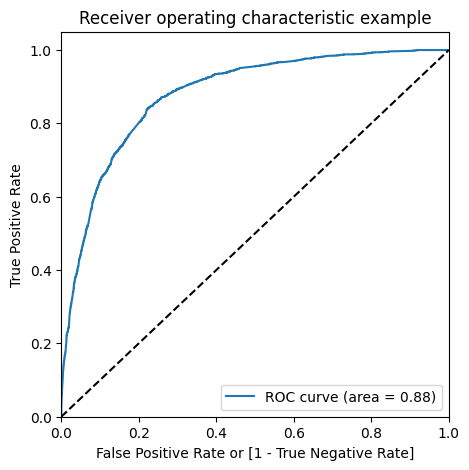

In [297]:
draw_roc(y_train_pred_final.Converted, y_train_pred_final.Converted_Prob)

In [298]:
numbers = [float(x)/10 for x in range(10)]
for i in numbers:
    y_train_pred_final[i]= y_train_pred_final.Converted_Prob.map(lambda x: 1 if x > i else 0)
y_train_pred_final.head()

,Prospect ID,Converted,Converted_Prob,predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0,0.384136,0,1,1,1,1,0,0,0,0,0,0
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0,0.271679,0,1,1,1,0,0,0,0,0,0,0
2,db308a34-ade6-4f0d-9779-586c5be188c7,0,0.435927,0,1,1,1,1,1,0,0,0,0,0
3,1199b37d-f610-4bb8-bf18-15267dec61fa,0,0.894678,1,1,1,1,1,1,1,1,1,1,0
4,6b2d3b2f-9990-449c-9333-012b578e39c8,0,0.230740,0,1,1,1,0,0,0,0,0,0,0


In [300]:
cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])
from sklearn.metrics import confusion_matrix

num = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in num:
    cm1 = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final[i] )
    total1=sum(sum(cm1))
    accuracy = (cm1[0,0]+cm1[1,1])/total1

    speci = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    sensi = cm1[1,1]/(cm1[1,0]+cm1[1,1])
    cutoff_df.loc[i] =[ i ,accuracy,sensi,speci]
print(cutoff_df)

     prob  accuracy     sensi     speci
0.0   0.0  0.381262  1.000000  0.000000
0.1   0.1  0.606370  0.973642  0.380060
0.2   0.2  0.739641  0.922141  0.627186
0.3   0.3  0.791280  0.865369  0.745627
0.4   0.4  0.803649  0.761963  0.829335
0.5   0.5  0.802257  0.680049  0.877561
0.6   0.6  0.795145  0.602595  0.913793
0.7   0.7  0.768398  0.491079  0.939280
0.8   0.8  0.739332  0.373074  0.965017
0.9   0.9  0.691249  0.211679  0.986757


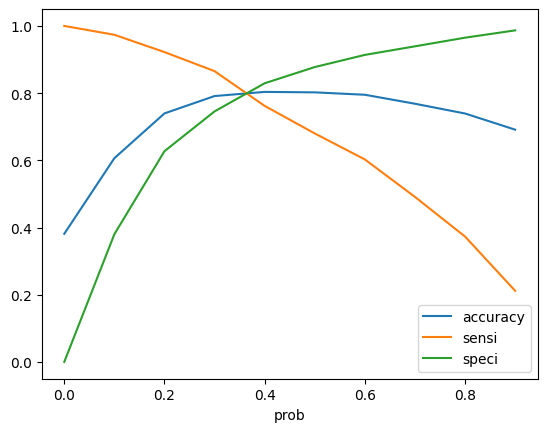

In [301]:
cutoff_df.plot.line(x='prob', y=['accuracy','sensi','speci'])
plt.show()

In [302]:
y_train_pred_final['final_predicted'] = y_train_pred_final.Converted_Prob.map( lambda x: 1 if x > 0.35 else 0)

y_train_pred_final.head()

,Prospect ID,Converted,Converted_Prob,predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,final_predicted
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0,0.384136,0,1,1,1,1,0,0,0,0,0,0,1
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0,0.271679,0,1,1,1,0,0,0,0,0,0,0,0
2,db308a34-ade6-4f0d-9779-586c5be188c7,0,0.435927,0,1,1,1,1,1,0,0,0,0,0,1
3,1199b37d-f610-4bb8-bf18-15267dec61fa,0,0.894678,1,1,1,1,1,1,1,1,1,1,0,1
4,6b2d3b2f-9990-449c-9333-012b578e39c8,0,0.230740,0,1,1,1,0,0,0,0,0,0,0,0


In [303]:
metrics.accuracy_score(y_train_pred_final.Converted, y_train_pred_final.final_predicted)

0.8010204081632653

In [304]:
confusion2 = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.final_predicted )
confusion2

array([[3118,  884],
       [ 403, 2063]])

In [305]:
TP = confusion2[1,1] # true positive
TN = confusion2[0,0] # true negatives
FP = confusion2[0,1] # false positives
FN = confusion2[1,0] # false negatives

In [306]:
TP / float(TP+FN)

np.float64(0.8365774533657745)

In [307]:
TN / float(TN+FP)

np.float64(0.7791104447776112)

In [308]:
print(FP/ float(TN+FP))

0.22088955522238882


In [309]:
print (TP / float(TP+FP))

0.7000339328130302


In [310]:
print (TN / float(TN+ FN))

0.8855438795796648


In [311]:
y_train_pred_final.shape

(6468, 15)

In [312]:
from sklearn.metrics import precision_recall_curve

In [313]:
y_train_pred_final.Converted, y_train_pred_final.predicted

(0       0
 1       0
 2       0
 3       0
 4       0
        ..
 6463    1
 6464    1
 6465    1
 6466    0
 6467    0
 Name: Converted, Length: 6468, dtype: int64,
 0       0
 1       0
 2       0
 3       1
 4       0
        ..
 6463    1
 6464    1
 6465    0
 6466    0
 6467    0
 Name: predicted, Length: 6468, dtype: int64)

In [314]:
p, r, thresholds = precision_recall_curve(y_train_pred_final.Converted, y_train_pred_final.Converted_Prob)

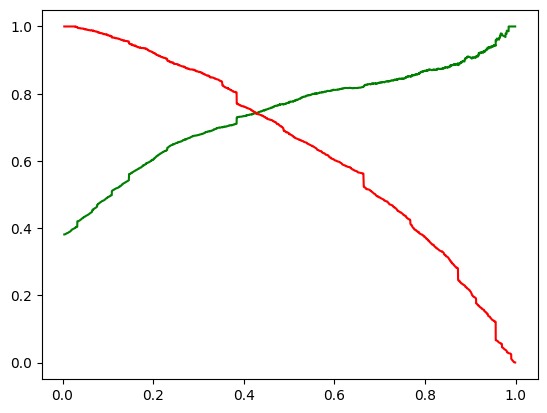

In [315]:
plt.plot(thresholds, p[:-1], "g-")
plt.plot(thresholds, r[:-1], "r-")
plt.show()

In [316]:
Recall = TP / float(TP+FN)
Recall

np.float64(0.8365774533657745)

In [317]:
Precision = TP / float(TP+FP)
Precision

np.float64(0.7000339328130302)

In [318]:
F1_score = (2* Recall * Precision)/ (Recall+Precision)
F1_score

np.float64(0.7622390541289488)

In [319]:
X_test.head()

,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Direct Traffic,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Reference,Lead Source_Referral Sites,Lead Source_Welingak Website,Last Activity_Converted to Lead,Last Activity_Email Bounced,Last Activity_Email Link Clicked,Last Activity_Email Marked Spam,Last Activity_Email Opened,Last Activity_Email Received,Last Activity_Form Submitted on Website,Last Activity_Had a Phone Conversation,Last Activity_Not Specified,Last Activity_Olark Chat Conversation,Last Activity_Page Visited on Website,Last Activity_Resubscribed to emails,Last Activity_SMS Sent,Last Activity_Unreachable,Last Activity_Unsubscribed,Last Activity_View in browser link Clicked,Last Activity_Visited Booth in Tradeshow,Country_Not Specified,Country_Other,What is your current occupation_Not Specified,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_View in browser link Clicked
Prospect ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
dd53b3eb-ae22-474c-b872-48b05bbe180b,0,8.0,1011,8.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
7a960b03-466c-4e36-bf12-b755fc77a0b1,0,0.0,0,0.0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,0,5.0,59,5.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0,0.0,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0
f7ed6c72-7d36-413c-b2e0-414213c4ceef,0,0.0,0,0.0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0


In [320]:
X_test[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']] = scaler.transform(X_test[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']])
X_test.head()

,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Direct Traffic,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Reference,Lead Source_Referral Sites,Lead Source_Welingak Website,Last Activity_Converted to Lead,Last Activity_Email Bounced,Last Activity_Email Link Clicked,Last Activity_Email Marked Spam,Last Activity_Email Opened,Last Activity_Email Received,Last Activity_Form Submitted on Website,Last Activity_Had a Phone Conversation,Last Activity_Not Specified,Last Activity_Olark Chat Conversation,Last Activity_Page Visited on Website,Last Activity_Resubscribed to emails,Last Activity_SMS Sent,Last Activity_Unreachable,Last Activity_Unsubscribed,Last Activity_View in browser link Clicked,Last Activity_Visited Booth in Tradeshow,Country_Not Specified,Country_Other,What is your current occupation_Not Specified,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Last Notable Activity_Email Bounced,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_View in browser link Clicked
Prospect ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
dd53b3eb-ae22-474c-b872-48b05bbe180b,0,0.857967,0.964504,2.613424,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
7a960b03-466c-4e36-bf12-b755fc77a0b1,0,-0.656434,-0.885371,-1.085519,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,0,0.290067,-0.777416,1.226321,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0,-0.656434,-0.885371,-1.085519,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0
f7ed6c72-7d36-413c-b2e0-414213c4ceef,0,-0.656434,-0.885371,-1.085519,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0


In [321]:
X_test = X_test[col]
X_test.head()

,Do Not Email,Total Time Spent on Website,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Source_Direct Traffic,Lead Source_Organic Search,Lead Source_Welingak Website,Last Activity_Converted to Lead,Last Activity_Olark Chat Conversation,Last Activity_SMS Sent,Last Activity_Unsubscribed,Country_Not Specified,What is your current occupation_Not Specified,What is your current occupation_Other,Last Notable Activity_Modified
Prospect ID,,,,,,,,,,,,,,,
dd53b3eb-ae22-474c-b872-48b05bbe180b,0,0.964504,0,0,1,0,0,0,0,1,0,0,1,0,0
7a960b03-466c-4e36-bf12-b755fc77a0b1,0,-0.885371,1,0,0,0,0,0,0,1,0,1,0,0,0
2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,0,-0.777416,0,0,0,0,0,0,0,0,0,0,0,0,0
6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0,-0.885371,0,0,0,0,0,0,1,0,0,1,0,0,1
f7ed6c72-7d36-413c-b2e0-414213c4ceef,0,-0.885371,1,0,0,0,0,0,0,0,0,1,0,0,0


In [322]:
X_test_sm = sm.add_constant(X_test)

In [323]:
y_test_pred = res.predict(X_test_sm)

In [324]:
y_test_pred.head()

,0
Prospect ID,
dd53b3eb-ae22-474c-b872-48b05bbe180b,0.483647
7a960b03-466c-4e36-bf12-b755fc77a0b1,0.956028
2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,0.200769
6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0.108734
f7ed6c72-7d36-413c-b2e0-414213c4ceef,0.872796


In [325]:
y_test_pred =y_test_pred.reset_index()
y_test_pred.head()

,Prospect ID,0
0,dd53b3eb-ae22-474c-b872-48b05bbe180b,0.483647
1,7a960b03-466c-4e36-bf12-b755fc77a0b1,0.956028
2,2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,0.200769
3,6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0.108734
4,f7ed6c72-7d36-413c-b2e0-414213c4ceef,0.872796


In [326]:
y_test = y_test.reset_index()
y_test.head()

,Prospect ID,Converted
0,dd53b3eb-ae22-474c-b872-48b05bbe180b,1
1,7a960b03-466c-4e36-bf12-b755fc77a0b1,1
2,2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,1
3,6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0
4,f7ed6c72-7d36-413c-b2e0-414213c4ceef,1


In [327]:
y_test_pred= y_test_pred.rename(columns={ 0 : 'Converted_Prob'})
y_test_pred.head()

,Prospect ID,Converted_Prob
0,dd53b3eb-ae22-474c-b872-48b05bbe180b,0.483647
1,7a960b03-466c-4e36-bf12-b755fc77a0b1,0.956028
2,2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,0.200769
3,6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0.108734
4,f7ed6c72-7d36-413c-b2e0-414213c4ceef,0.872796


In [328]:
y_test_pred_final = pd.merge(y_test, y_test_pred, how='inner', on='Prospect ID')
y_test_pred_final.head()

,Prospect ID,Converted,Converted_Prob
0,dd53b3eb-ae22-474c-b872-48b05bbe180b,1,0.483647
1,7a960b03-466c-4e36-bf12-b755fc77a0b1,1,0.956028
2,2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,1,0.200769
3,6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0,0.108734
4,f7ed6c72-7d36-413c-b2e0-414213c4ceef,1,0.872796


In [329]:
y_test_pred_final['final_predicted'] = y_test_pred_final.Converted_Prob.map(lambda x: 1 if x > 0.35 else 0)
y_test_pred_final.head()

,Prospect ID,Converted,Converted_Prob,final_predicted
0,dd53b3eb-ae22-474c-b872-48b05bbe180b,1,0.483647,1
1,7a960b03-466c-4e36-bf12-b755fc77a0b1,1,0.956028,1
2,2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,1,0.200769,0
3,6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0,0.108734,0
4,f7ed6c72-7d36-413c-b2e0-414213c4ceef,1,0.872796,1


In [330]:
metrics.accuracy_score(y_test_pred_final.Converted, y_test_pred_final.final_predicted)

0.8091630591630592

In [331]:
confusion2 = metrics.confusion_matrix(y_test_pred_final.Converted, y_test_pred_final.final_predicted )
confusion2

array([[1327,  350],
       [ 179,  916]])

In [332]:
TP = confusion2[1,1] # true positive
TN = confusion2[0,0] # true negatives
FP = confusion2[0,1] # false positives
FN = confusion2[1,0] # false negatives

In [333]:

TP / float(TP+FN)

np.float64(0.8365296803652968)

In [334]:
TN / float(TN+FP)

np.float64(0.791293977340489)

In [335]:
y_train_pred_final.head()

,Prospect ID,Converted,Converted_Prob,predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,final_predicted
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,0,0.384136,0,1,1,1,1,0,0,0,0,0,0,1
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,0,0.271679,0,1,1,1,0,0,0,0,0,0,0,0
2,db308a34-ade6-4f0d-9779-586c5be188c7,0,0.435927,0,1,1,1,1,1,0,0,0,0,0,1
3,1199b37d-f610-4bb8-bf18-15267dec61fa,0,0.894678,1,1,1,1,1,1,1,1,1,1,0,1
4,6b2d3b2f-9990-449c-9333-012b578e39c8,0,0.230740,0,1,1,1,0,0,0,0,0,0,0,0


In [336]:
Train_score = y_train_pred_final[['Prospect ID', 'Converted_Prob']]

In [337]:
Train_score['Converted_Prob'] = Train_score['Converted_Prob'] * 100

In [338]:
Train_score = Train_score.rename(columns = {'Converted_Prob': 'Score'}, inplace = False)

In [339]:
Train_score.head()

,Prospect ID,Score
0,f3af2d98-02db-45d7-bbf6-c641d6b4f4c3,38.413636
1,207aaf73-a121-41b8-96bb-b0d5c38e7a7b,27.167919
2,db308a34-ade6-4f0d-9779-586c5be188c7,43.592690
3,1199b37d-f610-4bb8-bf18-15267dec61fa,89.467804
4,6b2d3b2f-9990-449c-9333-012b578e39c8,23.073989


In [340]:
y_test_pred_final.head()

,Prospect ID,Converted,Converted_Prob,final_predicted
0,dd53b3eb-ae22-474c-b872-48b05bbe180b,1,0.483647,1
1,7a960b03-466c-4e36-bf12-b755fc77a0b1,1,0.956028,1
2,2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,1,0.200769,0
3,6eb89ae5-d1e0-4c19-8661-8f9545e0e408,0,0.108734,0
4,f7ed6c72-7d36-413c-b2e0-414213c4ceef,1,0.872796,1


In [341]:
Test_score = y_test_pred_final[['Prospect ID', 'Converted_Prob']]
Test_score['Converted_Prob'] = Test_score['Converted_Prob'] * 100
Test_score = Test_score.rename(columns = {'Converted_Prob': 'Score'}, inplace = False)

In [342]:
Test_score.head()

,Prospect ID,Score
0,dd53b3eb-ae22-474c-b872-48b05bbe180b,48.364742
1,7a960b03-466c-4e36-bf12-b755fc77a0b1,95.602819
2,2bd5fd90-a8fe-413e-9b8a-28e8469c5a5c,20.076862
3,6eb89ae5-d1e0-4c19-8661-8f9545e0e408,10.873443
4,f7ed6c72-7d36-413c-b2e0-414213c4ceef,87.279647


In [343]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6452
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2752.9
Date:                Sun, 30 Aug 2026   Deviance:                       5505.7
Time:                        16:32:24   Pearson chi2:                 6.38e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3801
Covariance Type:            nonrobust                                         
=================================================================================================================
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
const                                            -0.5225      0.068     -7.655      0.000      -0.656      -0.389
Do Not Email                                     -1.4106      0.174     -8.120      0.000      -1.751      -1.070
Total Time Spent on Website                       1.1050      0.039     27.996      0.000       1.028       1.182
Lead Origin_Lead Add Form                         2.3979      0.193     12.448      0.000       2.020       2.776
Lead Origin_Lead Import                          -1.2865      0.505     -2.548      0.011      -2.276      -0.297
Lead Source_Direct Traffic                       -0.4700      0.085     -5.557      0.000      -0.636      -0.304
Lead Source_Organic Search                       -0.2565      0.108     -2.374      0.018      -0.468      -0.045
Lead Source_Welingak Website                      1.5418      0.741      2.082      0.037       0.090       2.994
Last Activity_Converted to Lead                  -0.6030      0.217     -2.777      0.005      -1.029      -0.177
Last Activity_Olark Chat Conversation            -0.8996      0.168     -5.363      0.000      -1.228      -0.571
Last Activity_SMS Sent                            1.1533      0.073     15.763      0.000       1.010       1.297
Last Activity_Unsubscribed                        0.9382      0.460      2.041      0.041       0.037       1.839
Country_Not Specified                             1.0288      0.109      9.455      0.000       0.816       1.242
What is your current occupation_Not Specified    -1.2921      0.086    -14.999      0.000      -1.461      -1.123
What is your current occupation_Other             1.1524      0.601      1.916      0.055      -0.026       2.331
Last Notable Activity_Modified                   -0.7321      0.083     -8.802      0.000      -0.895      -0.569
=================================================================================================================
"""